# AML Projektarbeit: Früherkennung von Windturbinenausfällen

**Kevin Kita (132261089), Jakob Fankhauser (132261103)** | Sommersemester 2026 

---

## 1. Einleitung

Windkraftanlagen erzeugen im laufenden Betrieb große Mengen an Sensordaten. Diese Daten bieten die Möglichkeit, sich anbahnende Schäden frühzeitig zu erkennen, bevor es zu einem kostspieligen Ausfall kommt. Die vorliegende Arbeit untersucht, inwieweit verschiedene Machine-Learning-Verfahren diese Aufgabe lösen können.

### 1.1 Problemstellung und Relevanz

Windkraftanlagen gehören zu den zentralen Bausteinen der Energiewende. Bei einem Ausfall eines Windrades entstehen neben den unmittelbaren Reparatur- und Ersatzteilkosten auch Kosten durch die entgangene Einspeisevergütung während der Ausfallzeit. Daher hängt der wirtschaftliche Betrieb von einer hohen Verfügbarkeit ab. Insbesondere bei Offshore-Windkraftanlagen kann es zu wetterbedingten Verzögerungen kommen, bei denen einzelne Reparaturen mehrere Wochen dauern können, was den wirtschaftlichen Schaden noch vergrößert.

SCADA-Systeme (Supervisory Control and Data Acquisition) verbessern als Kernstück des Energiemanagementsystems die Effizienz und Zuverlässigkeit der einzelnen Windräder. Sie erzeugen in einem Intervall von Sekunden bis Minuten eine Vielzahl von Sensorsignalen, darunter Leistungskennzahlen wie Drehzahl, Öltemperatur, Neigung und Gierwinkel.

Eine manuelle Überwachung dieser Sensoren ist aufgrund der hohen Datenmenge unpraktikabel, und eine einfache Schwellenwertregel könnte zu spät greifen, da sich mechanische Schäden meist über einen längeren Zeitraum anbahnen. Daher ist das zu lösende Problem eine frühzeitige Klassifizierung anomaler Betriebszustände in dem Zeitraum, in dem die Bauteile bereits degradieren, aber noch kein Ausfall eingetreten ist.

### 1.2 Zielsetzung

Das Ziel ist es, ein System zu entwickeln, das den Zustand einer Windturbine kontinuierlich aus den Sensordaten ableitet und einen Defekt möglichst frühzeitig signalisiert. Dafür werden zwei methodische Ansätze gegenübergestellt.

Den ersten Ansatz bildet ein **semi-supervised Verfahren**. Hier lernt das Modell ausschließlich aus dem Normalbetrieb und wertet jede Abweichung davon als Anomalie. Der Gedanke dahinter ist einfach: Das Modell merkt sich, wie sich eine gesunde Turbine verhält, und schlägt Alarm, wenn die Sensordaten davon abweichen. Dafür kommen Isolation Forest, One-Class SVM und ein Conv-Autoencoder zum Einsatz.

Den zweiten Ansatz bildet ein **supervised Vergleich**. Über sogenannte Pseudo-Labels wird der Zeitraum rund um den Ausfall als Anomalie und der Normalbetrieb als unauffällig markiert. Damit entsteht ein klassisches binäres Klassifikationsproblem, das mit Random Forest, LightGBM, 1D-CNN und LSTM gelöst wird.

Die zentrale Forschungsfrage lautet: **Bringt die explizite Modellierung der Zeitstruktur durch CNN, LSTM und Conv-Autoencoder einen Mehrwert gegenüber Modellen, die nur mit zeitlich isolierten Fenster-Statistiken arbeiten?**

### 1.3 Erwartete Herausforderungen

**Klassenungleichverteilung:** Windkraftanlagen sind robust konstruiert, deshalb tritt ein Ausfall im Verhältnis zur Gesamtbetriebszeit sehr selten auf. Das bedeutet, es gibt viel mehr Normaldaten als Fehlerdaten. Ein naives Modell könnte einfach immer "normal" sagen und hätte trotzdem eine hohe Genauigkeit. Deshalb darf man nicht nur die Accuracy betrachten, sondern muss Metriken wie den F1-Score und die ROC-AUC verwenden, die auch die seltenen Fehlerfälle berücksichtigen.

**Unterschiedliche Ausfallmodi:** Die Anomalie-Ereignisse verteilen sich auf verschiedene Ausfalltypen. Ein Getriebeschaden zeigt sich an steigenden Öl- und Lagertemperaturen, ein Hydraulikschaden eher in steigendem Druck. Ein einziges Modell muss also viele verschiedene Muster gleichzeitig erkennen können.

**Dimensionalität:** Jeder Zeitpunkt wird durch 81 Sensorgrößen mit sehr unterschiedlichen Wertebereichen beschrieben (von wenigen Grad Celsius bis zu Tausenden von Umdrehungen pro Minute). Ohne Skalierung würden Features mit großen Wertebereichen die Verlustfunktion der neuronalen Netze dominieren.

**Zeitliche Reihenfolge:** Die Daten dürfen nicht einfach zufällig gemischt werden. Das Modell muss aus der Vergangenheit lernen und auf die Zukunft anwenden, sonst wäre das Ergebnis unrealistisch optimistisch.

**Übertragbarkeit:** Es ist unklar, ob ein Modell, das auf einer Turbine trainiert wurde, auch bei einer anderen Turbine funktioniert, da sich Alter, Standort und Betriebsbedingungen unterscheiden.

### 1.4 Datenquelle

Die Datengrundlage ist der öffentlich verfügbare CARE-Datensatz (Gück, C.; Roelofs, C.M.A.; Faulstich, S., 2024), bereitgestellt unter https://zenodo.org/records/15846963 (Lizenz: CC BY-SA 4.0). Er umfasst 89 Jahre kumulierter Betriebszeit von 36 Windturbinen aus drei Windparks (A, B, C) mit einer Auflösung von 10 Minuten. Insgesamt liegen 95 Datensätze vor, davon 44 mit einem gelabelten Anomalie-Ereignis und 51 mit reinem Normalbetrieb.

Die explorative Analyse erfolgt an Windpark A (22 Dateien, 5 Turbinen, 11 Anomalien, 81 Sensor-Features). Zur Prüfung der Übertragbarkeit wird zusätzlich Windpark B als Replikation herangezogen (257 Features, 6 Anomalien).

### 1.5 Lösungsansatz

**Labeldefinition:** Der Stillstand (Status 4) markiert den Eingriffszeitpunkt — für eine Frühwarnung ist das zu spät. Als Anomalie-Label dient deshalb der vom Datensatz vorgegebene Prediction-Teil. Warum? Weil der tatsächliche Degradationsbeginn unbekannt ist und ein willkürlich gewähltes Vorlaufzeitfenster (z. B. 7 Tage vor dem Ausfall) das Problem nur verschiebt, aber nicht löst.

**Status-Filterung:** Training nur auf Normalbetrieb (Status 0), damit das Modell ein sauberes Bild des gesunden Betriebs lernt und nicht durch Wartungs- oder Fehlerphasen verwirrt wird.

**Binärklassifikation statt Multiclass:** Bei nur einem Trainingsbeispiel für den Transformatorausfall würde ein Multiclass-Modell den Einzelfall auswendig lernen statt ein übertragbares Muster.

**Validierung (LOAO):** In jedem Durchlauf wird genau ein Anomalie-Ereignis herausgehalten und getestet. Damit wird sichergestellt, dass das Modell das getestete Ereignis wirklich nicht kennt. Das ergibt 11 Folds für Park A und 6 für Park B. Die Skalierung wird strikt nur auf den Trainingsdaten des jeweiligen Folds berechnet, um Informationslecks zu vermeiden.

**Pooled Predictions:** Da bei einzelnen Folds nicht immer sinnvolle Metriken berechenbar sind, werden die Vorhersagen aller Folds gesammelt und die Metriken einmal über alle gesammelten Vorhersagen berechnet.

## 0 · Setup & Konfiguration

Hier werden alle zentralen Einstellungen festgelegt: Pfade zu den Daten, die Fensterlänge (144 Schritte = 24 Stunden), die Schrittweite (6 = 1 Stunde) und ob die Modelle neu trainiert werden sollen. Mit `RETRAIN=False` lädt das Notebook die bereits berechneten Scores aus dem `artifacts`-Ordner und läuft in wenigen Minuten durch, ohne GPU und ohne neues Training.

In [ ]:
import os, shutil, warnings, itertools, json
from pathlib import Path

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from numpy.lib.stride_tricks import sliding_window_view

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

ON_KAGGLE = Path("/kaggle/input").exists()
KAGGLE_PQ_DATASET = Path("/kaggle/input/care-parquet")

CONFIG = {
    "RAW_DIR":  Path("/kaggle/input/care-to-compare") if ON_KAGGLE else Path("./CARE_To_Compare"),
    "PQ_DIR":   KAGGLE_PQ_DATASET if KAGGLE_PQ_DATASET.exists()
                else (Path("/kaggle/working/parquet") if ON_KAGGLE else Path("./parquet")),
    "ART_DIR":  Path("/kaggle/working/artifacts") if ON_KAGGLE else Path("./artifacts"),
    "FARMS":    ["A", "B"],
    "SEEDS":    [0],
    "WINDOW":   144,
    "STRIDE":   6,
    "CSV_SEP":  ";",
    "AE_EPOCHS": 15,
    "RETRAIN":  False,
}

META_COLS = {"time_stamp", "asset_id", "id", "train_test", "status_type_id"}
NORMAL_STATUS = 0             # status_type_id == 0 = echter Normalbetrieb
W, S = CONFIG["WINDOW"], CONFIG["STRIDE"]

PQ_WRITABLE = not str(CONFIG["PQ_DIR"]).startswith("/kaggle/input")
if PQ_WRITABLE:
    CONFIG["PQ_DIR"].mkdir(parents=True, exist_ok=True)
CONFIG["ART_DIR"].mkdir(parents=True, exist_ok=True)

def raw_farm(farm): return CONFIG["RAW_DIR"] / f"Wind Farm {farm}"
def pq_farm(farm):  return CONFIG["PQ_DIR"]  / f"Wind Farm {farm}"

print(f"Kaggle: {ON_KAGGLE} | PQ: {CONFIG['PQ_DIR']} | ART: {CONFIG['ART_DIR']} | RETRAIN={CONFIG['RETRAIN']}")

Kaggle: False | PQ: parquet | ART: artifacts | RETRAIN=False


### 0b · Vorhandene Score-Artefakte laden

Falls die Artefakte bereits vorliegen (z. B. von einem früheren Kaggle- oder Colab-Lauf), werden sie hier in den Arbeitsordner kopiert. Dadurch müssen die rechenintensiven Trainingsschritte nicht wiederholt werden. Lokal hat dieser Schritt keinen Effekt.

In [ ]:
import shutil
RESTORE_SRC = Path("/kaggle/input/care-artifacts")
if RESTORE_SRC.exists():
    CONFIG["ART_DIR"].mkdir(parents=True, exist_ok=True)
    n = 0
    for f in RESTORE_SRC.glob("*"):
        if f.suffix in (".npz", ".json"):
            shutil.copy(f, CONFIG["ART_DIR"] / f.name); n += 1
    print(f"{n} Score-Dateien zurueckgespielt nach {CONFIG['ART_DIR']}")
else:
    print("Kein Restore-Dataset gefunden (lokal normal) — nichts kopiert.")

for farm in CONFIG["FARMS"]:
    line = []
    for m in ["IsoForest", "OC-SVM", "ConvAE", "RF", "LightGBM", "CNN", "LSTM"]:
        ex = (CONFIG["ART_DIR"] / f"{farm}_{m}_arrays.npz").exists()
        line.append(f"{m}:{'OK' if ex else 'TODO'}")
    print(farm, " ".join(line))

Kein Restore-Dataset gefunden (lokal normal) — nichts kopiert.
A IsoForest:OK OC-SVM:OK ConvAE:OK RF:OK LightGBM:OK CNN:OK LSTM:OK
B IsoForest:OK OC-SVM:OK ConvAE:OK RF:OK LightGBM:OK CNN:OK LSTM:OK


## 1 · CSV → Parquet (einmalig)

Die Rohdaten liegen als semikolon-getrennte CSV-Dateien vor. Dieser Schritt konvertiert sie in das Parquet-Format, das deutlich kompakter ist und beim Laden wesentlich schneller gelesen werden kann. Wenn die Parquet-Dateien bereits existieren, wird der Schritt automatisch übersprungen.

In [3]:
def convert_farm(farm):
    src, dst = raw_farm(farm), pq_farm(farm)
    (dst / "datasets").mkdir(parents=True, exist_ok=True)
    for f in ["event_info.csv", "feature_description.csv"]:
        if not (dst / f).exists():
            shutil.copy(src / f, dst / f)
    files = sorted((src / "datasets").glob("*.csv"), key=lambda p: int(p.stem))
    for i, csv in enumerate(files, 1):
        out = dst / "datasets" / f"{csv.stem}.parquet"
        if out.exists():
            continue
        df = pd.read_csv(csv, sep=CONFIG["CSV_SEP"], parse_dates=["time_stamp"], low_memory=False)
        df.to_parquet(out, index=False)
        print(f"[{farm}] {i:>2}/{len(files)}  {csv.name:>8} -> {out.name:<12} "
              f"{csv.stat().st_size/1e6:6.1f} MB -> {out.stat().st_size/1e6:5.1f} MB")

if PQ_WRITABLE:
    for farm in CONFIG["FARMS"]:
        convert_farm(farm)
else:
    print("PQ_DIR ist read-only (Kaggle-Input) — Konvertierung uebersprungen.")

### Hilfsfunktionen

Zentrale Funktionen zum Laden der Event-Daten, zur Auswahl der Sensor-Spalten und zum Speichern/Laden der Modell-Scores. Die Score-Artefakte werden als `.npz`-Dateien gespeichert, damit ein erneuter Lauf die bereits trainierten Ergebnisse überspringen kann.

In [4]:
def load_event_data(farm, event_id, columns=None):
    return pd.read_parquet(pq_farm(farm) / "datasets" / f"{event_id}.parquet", columns=columns)

def feature_cols(df):
    return [c for c in df.columns if c not in META_COLS]

def save_scores(farm, model, per_fold):
    blob = {}
    for k, r in enumerate(per_fold):
        blob[f"{k}_scores"] = r["scores"].astype(np.float32)
        blob[f"{k}_y"]      = r["y"].astype(np.int8)
        blob[f"{k}_eids"]   = r["eids"].astype(np.int32)
    np.savez_compressed(CONFIG["ART_DIR"] / f"{farm}_{model}_arrays.npz", **blob)
    meta = {"farm": farm, "model": model,
            "folds": [{"fold": k, "thr": float(r["thr"]),
                       "test_anomaly": int(r.get("test_anomaly", -1))} for k, r in enumerate(per_fold)]}
    (CONFIG["ART_DIR"] / f"{farm}_{model}_meta.json").write_text(json.dumps(meta))

def load_scores(farm, model):
    arr = np.load(CONFIG["ART_DIR"] / f"{farm}_{model}_arrays.npz")
    meta = json.loads((CONFIG["ART_DIR"] / f"{farm}_{model}_meta.json").read_text())
    return [{"scores": arr[f"{m['fold']}_scores"], "y": arr[f"{m['fold']}_y"],
             "eids": arr[f"{m['fold']}_eids"], "thr": m["thr"], "test_anomaly": m["test_anomaly"]}
            for m in meta["folds"]]

def scores_exist(farm, model):
    return (CONFIG["ART_DIR"] / f"{farm}_{model}_arrays.npz").exists()

## 2 · Event-Übersicht

In diesem Abschnitt wird die zentrale Datei `event_info.csv` geladen, die alle Ereignisse tabellarisch zusammenfasst. Für jedes Ereignis sind die zugehörige Turbine, die Klassifikation als *anomaly* oder *normal*, der exakte Zeitraum über `event_start` und `event_end` sowie der Ausfalltyp hinterlegt.

In [5]:
def load_events(farm):
    ei = pd.read_csv(pq_farm(farm) / "event_info.csv", sep=CONFIG["CSV_SEP"])
    ei.columns = [c.strip().lower() for c in ei.columns]
    for c in ["event_start", "event_end"]:
        ei[c] = pd.to_datetime(ei[c])
    ei["farm"] = farm
    return ei

events = pd.concat([load_events(f) for f in CONFIG["FARMS"]], ignore_index=True)
display(events.head())


,event_id,event_label,event_start,event_start_id,event_end,event_end_id,event_description,farm
0,68,anomaly,2015-07-29 13:20:00,52063,2015-08-12 13:10:00,54076,Transformer failure,A
1,22,anomaly,2021-08-11 09:50:00,51888,2021-08-18 10:00:00,52892,Hydraulic group,A
2,72,anomaly,2021-10-09 08:40:00,52497,2021-10-16 08:40:00,53505,Gearbox failure,A
3,73,anomaly,2023-06-09 11:40:00,52745,2023-06-16 11:40:00,53753,Hydraulic group,A
4,0,anomaly,2022-08-05 06:10:00,52436,2022-08-19 06:10:00,54447,Generator bearing failure,A


In [6]:
display(events.groupby(["farm", "event_label"]).size().unstack(fill_value=0))
events["pred_days"] = (events["event_end"] - events["event_start"]).dt.days
display(events.groupby(["farm", "event_label"])["pred_days"].agg(["count", "mean", "min", "max"]).round(1))
display(events.loc[events["event_label"] == "anomaly"]
              .groupby(["farm", "event_description"]).size().rename("n").to_frame())

event_label,anomaly,normal
farm,,
A,11,11
B,6,9


count  mean  min  max
farm event_label                       
A    anomaly         11  10.4    7   31
     normal          11  13.3    7   20
B    anomaly          6  39.2   20   61
     normal           9  21.1    9   91

n
farm event_description                                    
A    Gearbox failure                                     2
     Generator bearing failure                           2
     Hydraulic group                                     6
     Transformer failure                                 1
B    Rotor Bearing 2 - Damage                            1
     Turbine is in standstill since 01.08 due to rot...  1
     Turbine is stopped due to a main bearing damage     1
     high temperature                                    3

## Explorative Datenanalyse (EDA)

Bevor Modelle trainiert werden, muss die Datenqualität geprüft und ein Verständnis für die Struktur der Daten aufgebaut werden. Die EDA untersucht fehlende Werte, die Verteilung der Betriebszustände, die Ausfalltypen, die Sensorgruppen, die Unterschiede zwischen Normal- und Anomaliebereichen, Korrelationen und zeitliche Muster. Die Erkenntnisse fließen direkt in die Modellierungsentscheidungen ein. 
Die explorative Datenanalyse wird beispielhaft an Windpark A durchgeführt. Dieser Park eignet sich dafür besonders gut, da er mit 81 Sensoren eine handhabbare Dimensionalität hat und mit elf Anomalie-Ereignissen die meisten Fehlerfälle aller drei Parks bietet. Windpark B wird erst im Trainings- und Ergebnisteil hinzugezogen, um zu prüfen, ob die Modelle auch auf einem strukturell anderen Park funktionieren.

In [ ]:
plt.rcParams.update({
    "font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10,
    "figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
})
try:
    plt.rcParams["font.family"] = "Arial"
except Exception:
    pass

COL_N = "#AAAAAA"
COL_A = "#444444"
EDA_EXTRA = {"event_id", "event_label"}  

FARM = "A"
ev_A = events[events["farm"] == FARM].copy()

all_dfs = {}
for _, row in ev_A.iterrows():
    eid = row["event_id"]
    df = load_event_data(FARM, eid)
    df["event_id"] = eid
    df["event_label"] = row["event_label"]
    all_dfs[eid] = df

sensor_cols = [c for c in feature_cols(list(all_dfs.values())[0])
               if c not in EDA_EXTRA]
print(f"Farm {FARM}: {len(ev_A)} Events, {len(sensor_cols)} Sensor-Features")

Farm A: 22 Events, 81 Sensor-Features


NaN-Werte gesamt:      40
Inf-Werte gesamt:      0
Konstante Sensoren (2): ['sensor_46', 'sensor_49']
Duplikate gesamt:      0


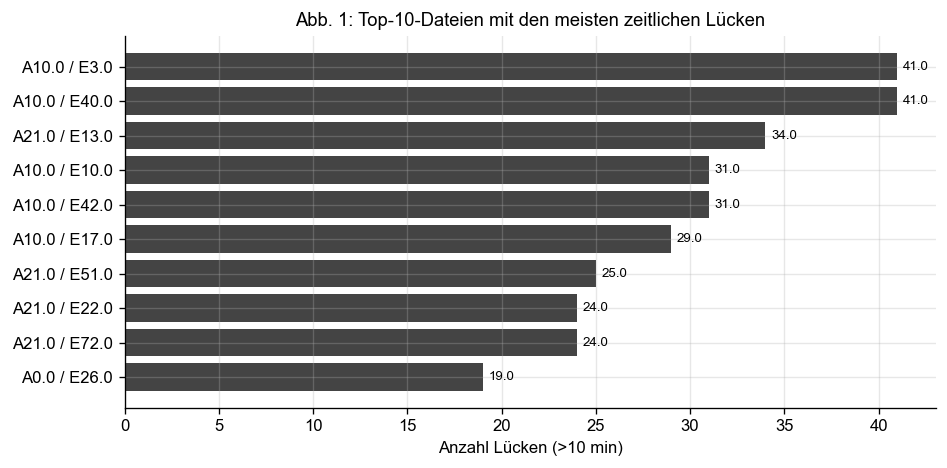

In [ ]:
nan_total = sum(df[sensor_cols].isna().sum().sum() for df in all_dfs.values())
inf_total = sum(np.isinf(df[sensor_cols].select_dtypes(include="number")).sum().sum()
                for df in all_dfs.values())
const_sensors = [c for c in sensor_cols
                 if all(df[c].dropna().nunique() <= 1 for df in all_dfs.values())]
dup_total = sum(df.duplicated(subset=["time_stamp"]).sum() for df in all_dfs.values())

print(f"NaN-Werte gesamt:      {nan_total}")
print(f"Inf-Werte gesamt:      {inf_total}")
print(f"Konstante Sensoren ({len(const_sensors)}): {const_sensors}")
print(f"Duplikate gesamt:      {dup_total}")

gap_info = []
for eid, df in all_dfs.items():
    ts = pd.to_datetime(df["time_stamp"]).sort_values()
    diffs = ts.diff().dt.total_seconds() / 60
    gaps = diffs[diffs > 10.5]
    max_gap_days = gaps.max() / 60 / 24 if len(gaps) > 0 else 0
    asset = df["asset_id"].iloc[0] if "asset_id" in df.columns else "?"
    gap_info.append({"event_id": int(eid), "asset_id": int(asset),
                     "n_gaps": len(gaps), "max_gap_days": round(max_gap_days, 1)})

gap_df = pd.DataFrame(gap_info).sort_values("n_gaps", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
top10 = gap_df.head(10).sort_values("n_gaps")
labels = [f"A{row['asset_id']} / E{row['event_id']}" for _, row in top10.iterrows()]
ax.barh(labels, top10["n_gaps"], color=COL_A)
for i, (_, row) in enumerate(top10.iterrows()):
    ax.text(row["n_gaps"] + 0.3, i, str(row["n_gaps"]), va="center", fontsize=8)
ax.set_xlabel("Anzahl Lücken (>10 min)")
ax.set_title("Abb. 1: Top-10-Dateien mit den meisten zeitlichen Lücken")
fig.tight_layout()
plt.show()

Die 40 fehlenden NaN-Werte und die zeitlichen Lücken sind zwei verschiedene Dinge. NaN-Werte bedeuten, dass innerhalb einer vorhandenen Zeile einzelne Sensorwerte fehlen — die Zeile existiert, aber ein Messwert ist leer. Zeitliche Lücken hingegen bedeuten, dass ganze Zeitstempel im 10-Minuten-Raster fehlen, also für diesen Zeitpunkt gar keine Zeile vorliegt.

Mit lediglich 40 fehlenden NaN-Werten bei über 1,2 Millionen Zeitstempeln und 81 Sensoren ist die Datenqualität auf Sensorebene sehr hoch. Die fehlenden Werte werden durch Fortschreiben des letzten bekannten Werts aufgefüllt (forward/backward fill). Die zeitlichen Lücken (10 bis 41 pro Datei) werden als kurze Betriebsunterbrechungen interpretiert und nicht gesondert behandelt, da sie gleichmäßig über alle Dateien verteilt sind und keine systematische Verzerrung erkennen lassen.

Die zwei konstanten Sensoren `sensor_46` und `sensor_49` tragen keine Information und werden vor dem Training entfernt.

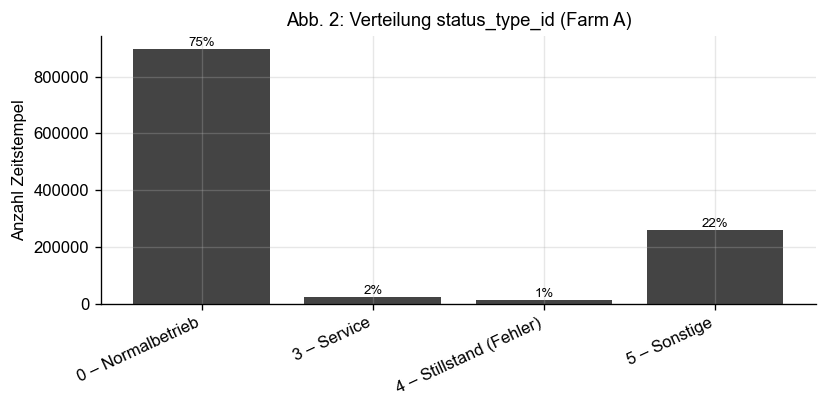

Vorhandene Betriebszustände:
  Status 0:    898,672 (75.1%)
  Status 3:     23,689 (2.0%)
  Status 4:     13,999 (1.2%)
  Status 5:    260,387 (21.8%)
  Nicht vorhanden: Status [1, 2]

Training ausschließlich auf Normalbetrieb (Status 0): 898,672 Zeitstempel


In [ ]:
status_counts = pd.concat(all_dfs.values())["status_type_id"].value_counts().sort_index()
status_labels = {0: "0 – Normalbetrieb", 1: "1 – Gedrosselt", 2: "2 – Leerlauf",
                 3: "3 – Service", 4: "4 – Stillstand (Fehler)", 5: "5 – Sonstige"}

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar([status_labels.get(s, str(s)) for s in status_counts.index],
              status_counts.values, color=COL_A)
for bar, v in zip(bars, status_counts.values):
    pct = v / status_counts.sum() * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{pct:.0f}%", ha="center", va="bottom", fontsize=8)
ax.set_ylabel("Anzahl Zeitstempel")
ax.set_title("Abb. 2: Verteilung status_type_id (Farm A)")
plt.xticks(rotation=25, ha="right")
fig.tight_layout()
plt.show()

total = status_counts.sum()
print("Vorhandene Betriebszustände:")
for s, c in status_counts.items():
    print(f"  Status {s}: {c:>10,} ({c/total*100:.1f}%)")
not_present = [s for s in range(6) if s not in status_counts.index]
if not_present:
    print(f"  Nicht vorhanden: Status {not_present}")
print(f"\nTraining ausschließlich auf Normalbetrieb (Status 0): {status_counts.get(0, 0):,} Zeitstempel")

Formal werden im Datensatz sechs Betriebszustände definiert, in Windpark A treten jedoch nur vier davon auf: Normalbetrieb (Status 0) mit 75 %, sonstige Betriebszustände (Status 5) mit 22 %, Service-Modus (Status 3) mit 2 % und Stillstand aufgrund eines Fehlers (Status 4) mit 1 %. Die Zustände gedrosselt (1) und Leerlauf (2) sind nicht vorhanden. Für das Training wird ausschließlich der Normalbetrieb (Status 0) verwendet. Der Grund dafür ist, dass das semi-supervised Modell lernen soll, wie sich eine gesunde Turbine verhält. Würden Service- oder Fehlerphasen im Training enthalten sein, könnte das Modell diese Muster fälschlich als "normal" abspeichern und sie später nicht mehr als Anomalie erkennen.

Ausfalltypen:
  Hydraulic group: 6
  Gearbox failure: 2
  Generator bearing failure: 2
  Transformer failure: 1
  Gesamt: 11 Anomalie-Events


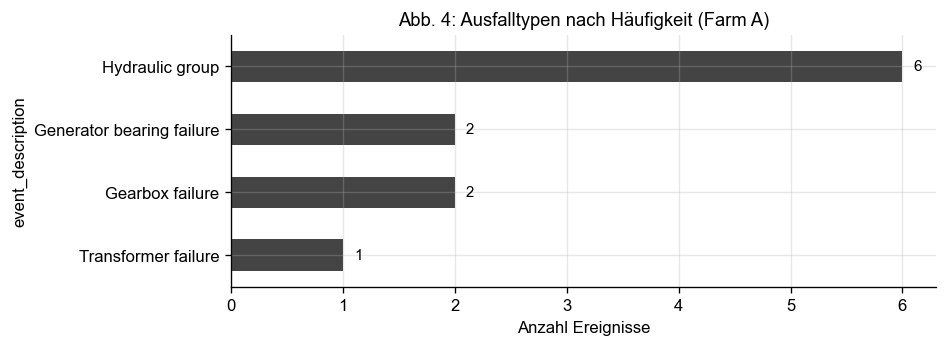

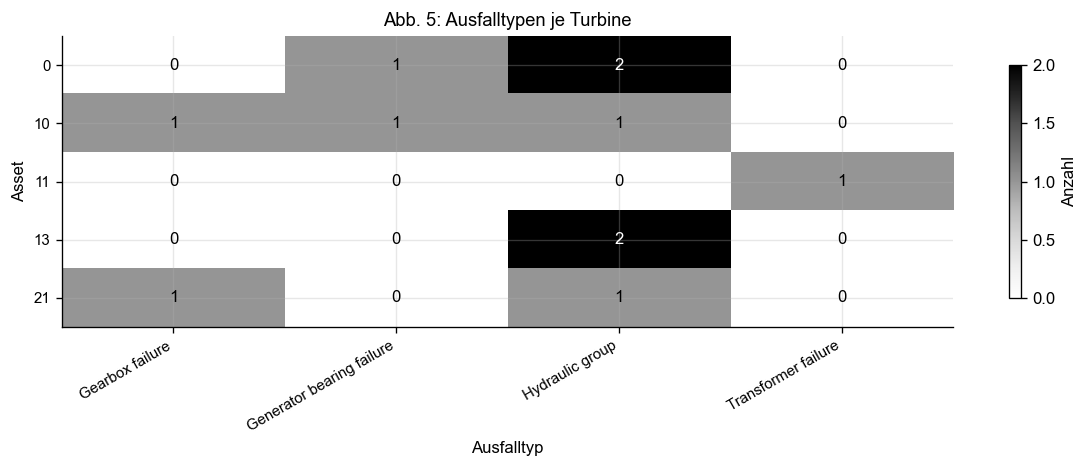

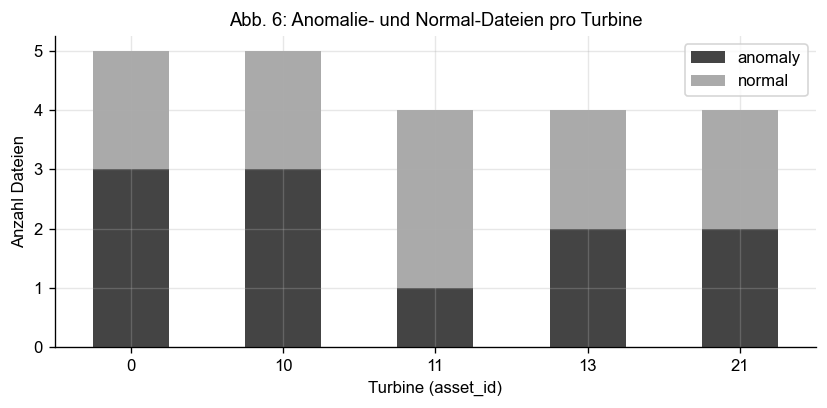

In [ ]:
anom = ev_A[ev_A["event_label"] == "anomaly"].copy()
anom["asset_id"] = anom["event_id"].apply(
    lambda eid: int(all_dfs[eid]["asset_id"].iloc[0]) if "asset_id" in all_dfs[eid].columns else "?")

desc_col_name = [c for c in anom.columns if "desc" in c.lower()]
desc_col_name = desc_col_name[0] if desc_col_name else "event_description"
type_counts = anom[desc_col_name].value_counts()

print("Ausfalltypen:")
for t, n in type_counts.items():
    print(f"  {t}: {n}")
print(f"  Gesamt: {type_counts.sum()} Anomalie-Events")

fig, ax = plt.subplots(figsize=(8, 3))
type_counts.sort_values().plot.barh(ax=ax, color=COL_A)
for i, v in enumerate(type_counts.sort_values().values):
    ax.text(v + 0.1, i, str(v), va="center", fontsize=9)
ax.set_xlabel("Anzahl Ereignisse")
ax.set_title("Abb. 4: Ausfalltypen nach Häufigkeit (Farm A)")
fig.tight_layout()
plt.show()

ct = pd.crosstab(anom["asset_id"], anom[desc_col_name])

all_assets = sorted(ev_A["event_id"].apply(
    lambda eid: int(all_dfs[eid]["asset_id"].iloc[0])).unique())
all_types = sorted(ct.columns)
ct = ct.reindex(index=all_assets, columns=all_types, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(ct.values, cmap="Greys", aspect="auto", vmin=0, vmax=ct.values.max())
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        val = ct.values[i, j]
        color = "white" if val > ct.values.max() / 2 else "black"
        ax.text(j, i, str(val), ha="center", va="center", fontsize=10, color=color)
ax.set_xticks(range(len(all_types)), all_types, rotation=30, ha="right", fontsize=9)
ax.set_yticks(range(len(all_assets)), all_assets, fontsize=9)
ax.set_xlabel("Ausfalltyp"); ax.set_ylabel("Asset")
ax.set_title("Abb. 5: Ausfalltypen je Turbine")
fig.colorbar(im, ax=ax, shrink=0.8, label="Anzahl")
fig.tight_layout()
plt.show()


ev_with_asset = ev_A.copy()
ev_with_asset["asset_id"] = ev_with_asset["event_id"].apply(
    lambda eid: int(all_dfs[eid]["asset_id"].iloc[0]) if "asset_id" in all_dfs[eid].columns else "?")
ct2 = pd.crosstab(ev_with_asset["asset_id"], ev_with_asset["event_label"])

fig, ax = plt.subplots(figsize=(7, 3.5))
ct2.plot.bar(stacked=True, ax=ax, color=[COL_A, COL_N])
ax.set_ylabel("Anzahl Dateien")
ax.set_xlabel("Turbine (asset_id)")
ax.set_title("Abb. 6: Anomalie- und Normal-Dateien pro Turbine")
ax.legend(["anomaly", "normal"])
plt.xticks(rotation=0)
fig.tight_layout()
plt.show()

Die elf Anomalie-Ereignisse in Windpark A verteilen sich auf vier Ausfalltypen, wie in Abbildung 4 zu sehen ist. Die Hydraulikgruppe ist mit sechs Ereignissen am häufigsten vertreten, gefolgt von je zwei Getriebeausfällen und Generatorlager-Ausfällen sowie einem Transformatorausfall.

**Warum ist das relevant?** Diese asymmetrische Verteilung bestätigt die Entscheidung gegen eine Multiclass-Klassifikation. Bei nur einem einzigen Trainingsbeispiel für den Transformatorausfall könnte das Modell nicht das allgemeine Degradationsmuster lernen, sondern würde den konkreten Einzelfall auswendig lernen. Deshalb wird ein binäres Modell trainiert, das nur zwischen "normal" und "anomal" unterscheidet — unabhängig vom konkreten Ausfalltyp.

Die Verteilung der Schadensarten über die fünf Turbinen (Abbildung 5) ist ungleichmäßig. Der Transformatorausfall tritt ausschließlich bei Turbine 11 auf, Generatorlager-Ausfälle konzentrieren sich auf die Turbinen 0 und 10. Für die LOAO-Validierung bedeutet das, dass im Test-Fold ein Ausfalltyp vorkommen kann, der im Training gar nicht oder nur selten vertreten war. Das ist eine bewusst akzeptierte Einschränkung, die im Fazit als Limitation aufgegriffen wird.

Bei der Betrachtung der Ereignis-Dateien pro Turbine (Abbildung 6) zeigt sich, dass die absolute Anzahl mit vier bis fünf Dateien pro Anlage relativ homogen ist. Die Verteilung der Labels weist jedoch Unterschiede auf: Bei Turbine 0 und 10 überwiegen die Anomalien, bei Turbine 11 dominiert der Normalbetrieb.

Grundsensoren gesamt: 54

Sensorgruppen:
  Generator           : 17
  Netz/Leistung       : 17
  Temperatur          : 6
  Wind                : 4
  Transformator       : 3
  Gondel              : 2
  Getriebe            : 2
  Pitch               : 1
  Hydraulik           : 1
  Yaw/Gier            : 1


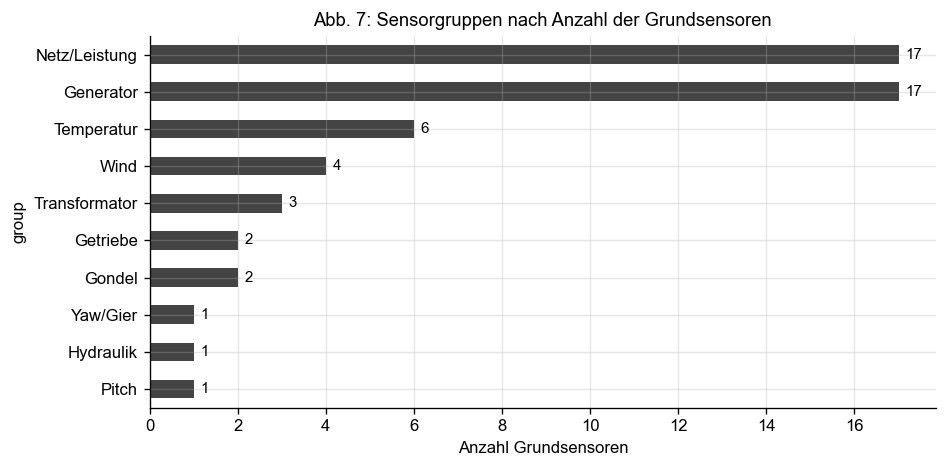


9 Schlüsselsensoren:
  Getriebeöl-Temp.          -> sensor_12_avg
  Hydrauliköl-Temp.         -> sensor_41_avg
  Getriebelager-Temp.       -> sensor_11_avg
  Generator-Drehzahl        -> sensor_18_avg
  Netzleistung              -> power_30_avg
  Windgeschwindigkeit       -> wind_speed_3_avg
  Umgebungs-Temp.           -> sensor_0_avg
  HV-Trafo-Temp.            -> sensor_38_avg
  Gondel-Temp.              -> sensor_43_avg


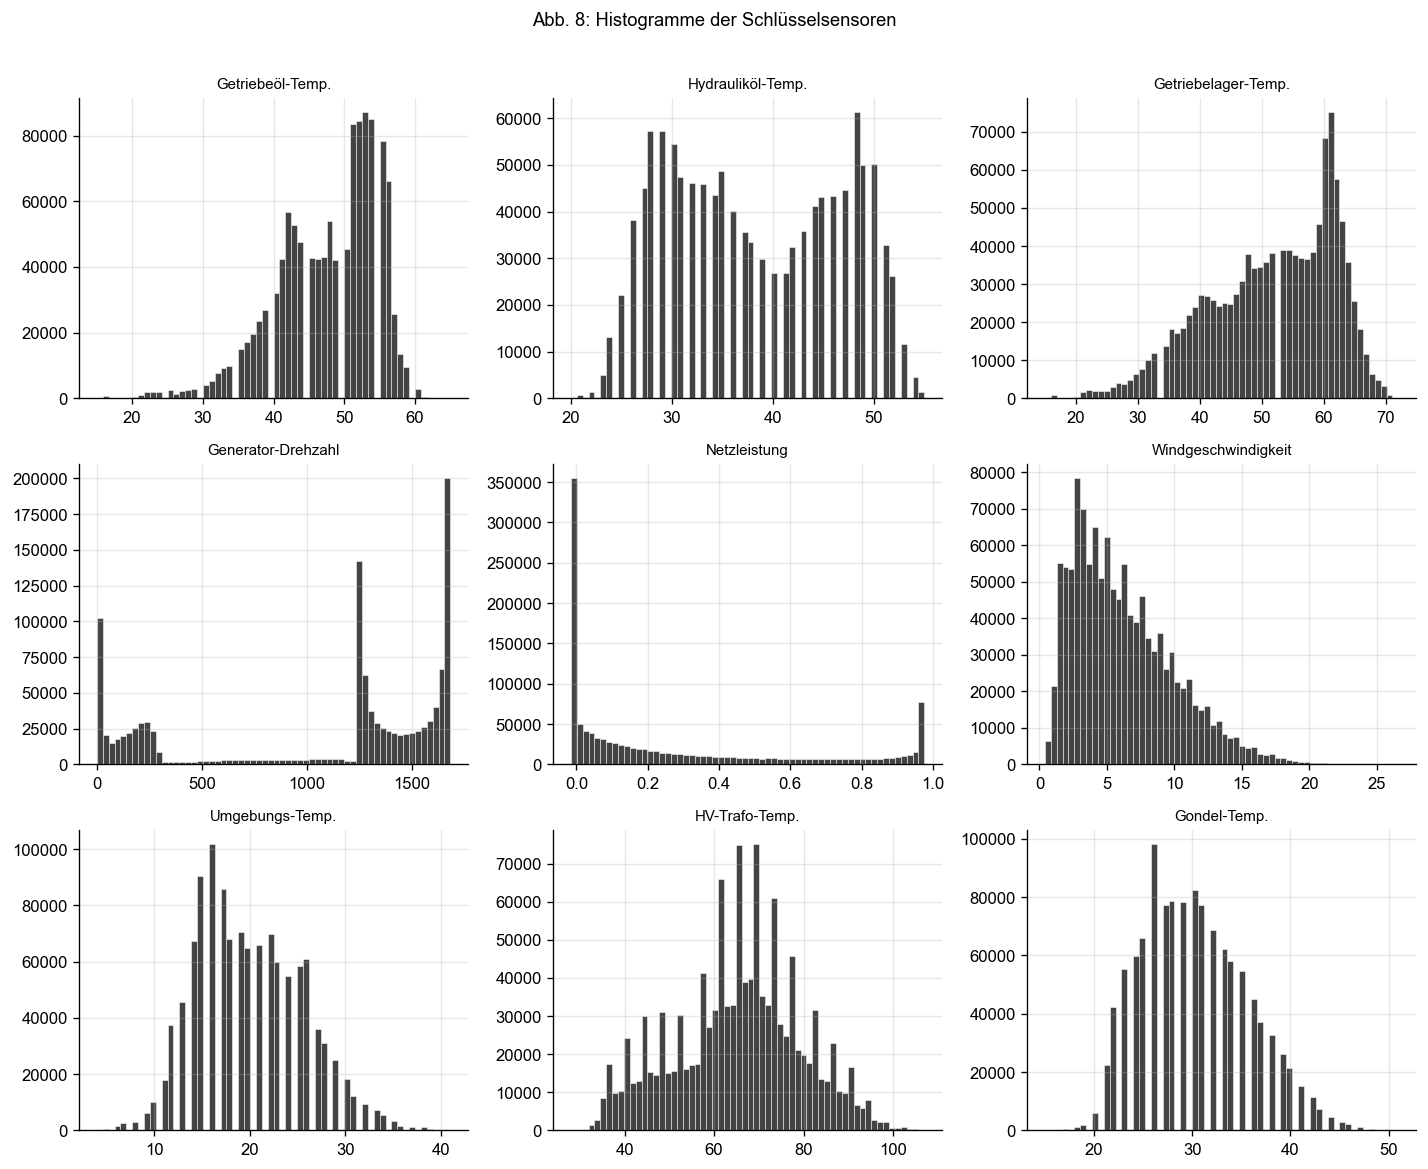

In [ ]:
feat_desc = pd.read_csv(pq_farm(FARM) / "feature_description.csv", sep=CONFIG["CSV_SEP"])
feat_desc.columns = [c.strip().lower() for c in feat_desc.columns]
desc_c = next((c for c in feat_desc.columns if "desc" in c or "comment" in c), feat_desc.columns[-1])
name_c = next((c for c in feat_desc.columns if "name" in c or "sensor" in c), feat_desc.columns[0])

def classify_sensor(row):
    txt = f"{row[name_c]} {row[desc_c]}".lower()
    if "gearbox" in txt or "gear" in txt:              return "Getriebe"
    if "hydraulic" in txt:                             return "Hydraulik"
    if "transformer" in txt:                           return "Transformator"
    if any(w in txt for w in ["generator", "stator",
            "split ring", "rotor"]):                   return "Generator"
    if any(w in txt for w in ["grid", "voltage",
            "current", "frequency", "phase dis",
            "busbar", "igbt", "power", "reactive"]):   return "Netz/Leistung"
    if "wind" in txt:                                  return "Wind"
    if "pitch" in txt:                                 return "Pitch"
    if "nacelle dir" in txt or "yaw" in txt:           return "Yaw/Gier"
    if "nacelle" in txt:                               return "Gondel"
    if "temp" in txt:                                  return "Temperatur"
    return "Sonstige"

feat_desc["group"] = feat_desc.apply(classify_sensor, axis=1)
group_counts = feat_desc["group"].value_counts()

print(f"Grundsensoren gesamt: {len(feat_desc)}")
print(f"\nSensorgruppen:")
for g, n in group_counts.items():
    print(f"  {g:20s}: {n}")


fig, ax = plt.subplots(figsize=(8, 4))
group_counts.sort_values().plot.barh(ax=ax, color=COL_A)
for i, v in enumerate(group_counts.sort_values().values):
    ax.text(v + 0.15, i, str(v), va="center", fontsize=9)
ax.set_xlabel("Anzahl Grundsensoren")
ax.set_title("Abb. 7: Sensorgruppen nach Anzahl der Grundsensoren")
fig.tight_layout()
plt.show()


manual_sensors = {
    "Getriebeöl-Temp.":     "sensor_12",
    "Hydrauliköl-Temp.":    "sensor_41",
    "Getriebelager-Temp.":  "sensor_11",
    "Generator-Drehzahl":   "sensor_18",
    "Netzleistung":         "power_30",
    "Windgeschwindigkeit":  "wind_speed_3",
    "Umgebungs-Temp.":      "sensor_0",
    "HV-Trafo-Temp.":       "sensor_38",
    "Gondel-Temp.":         "sensor_43",
}

sample = list(all_dfs.values())[0]
key_sensors = {}
for label, base in manual_sensors.items():
    for col in (base, f"{base}_avg"):
        if col in sample.columns:
            key_sensors[label] = col; break

print(f"\n{len(key_sensors)} Schlüsselsensoren:")
for label, col in key_sensors.items():
    print(f"  {label:25s} -> {col}")


big = pd.concat([df[list(key_sensors.values())] for df in all_dfs.values()], ignore_index=True)
ncols = 3
nrows = (len(key_sensors) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.2 * nrows))
axes = axes.flatten()
for i, (label, col) in enumerate(key_sensors.items()):
    axes[i].hist(big[col].dropna(), bins=60, color=COL_A, edgecolor="white", linewidth=0.3)
    axes[i].set_title(label, fontsize=9)
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
fig.suptitle("Abb. 8: Histogramme der Schlüsselsensoren", fontsize=11, y=1.01)
fig.tight_layout()
plt.show()

Gemäß Abbildung 7 lassen sich die 54 Grundsensoren thematisch in zehn Gruppen aufteilen. Generatorbezogene Messgrößen und netzelektrische Sensoren bilden die größten Gruppen. Auffällig ist, dass die Hydraulikgruppe trotz ihrer Dominanz unter den Ausfalltypen (sechs von elf Anomalie-Ereignissen) nur durch einen einzigen Temperatursensor repräsentiert ist. Das bedeutet: Das Modell muss Hydraulikprobleme primär über diesen einen Sensor und indirekte Effekte auf andere Sensorgruppen erkennen — eine klare Herausforderung.

Die Histogramme in Abbildung 8 zeigen die Heterogenität der Wertebereiche. Die Temperatursensoren weisen bimodale Verteilungen auf (vermutlich durch saisonale Schwankungen). Die Generator-Drehzahl zeigt drei Bereiche: 0 rpm bei Stillstand, ca. 1250 rpm bei Teillast und ca. 1700 rpm bei Volllast. Die Netzleistung hat einen starken Ausschlag nahe null (Schwachlast/Stillstand) und einen bei 1 (Volllast).

Diese extrem unterschiedlichen Wertebereiche machen eine Standardisierung vor dem Training der neuronalen Netze zwingend nötig. Ohne Skalierung würden Sensoren mit großen Zahlenwerten (z. B. Drehzahl in rpm) die Verlustfunktion dominieren und die kleinen, aber möglicherweise informativen Temperaturänderungen untergehen.

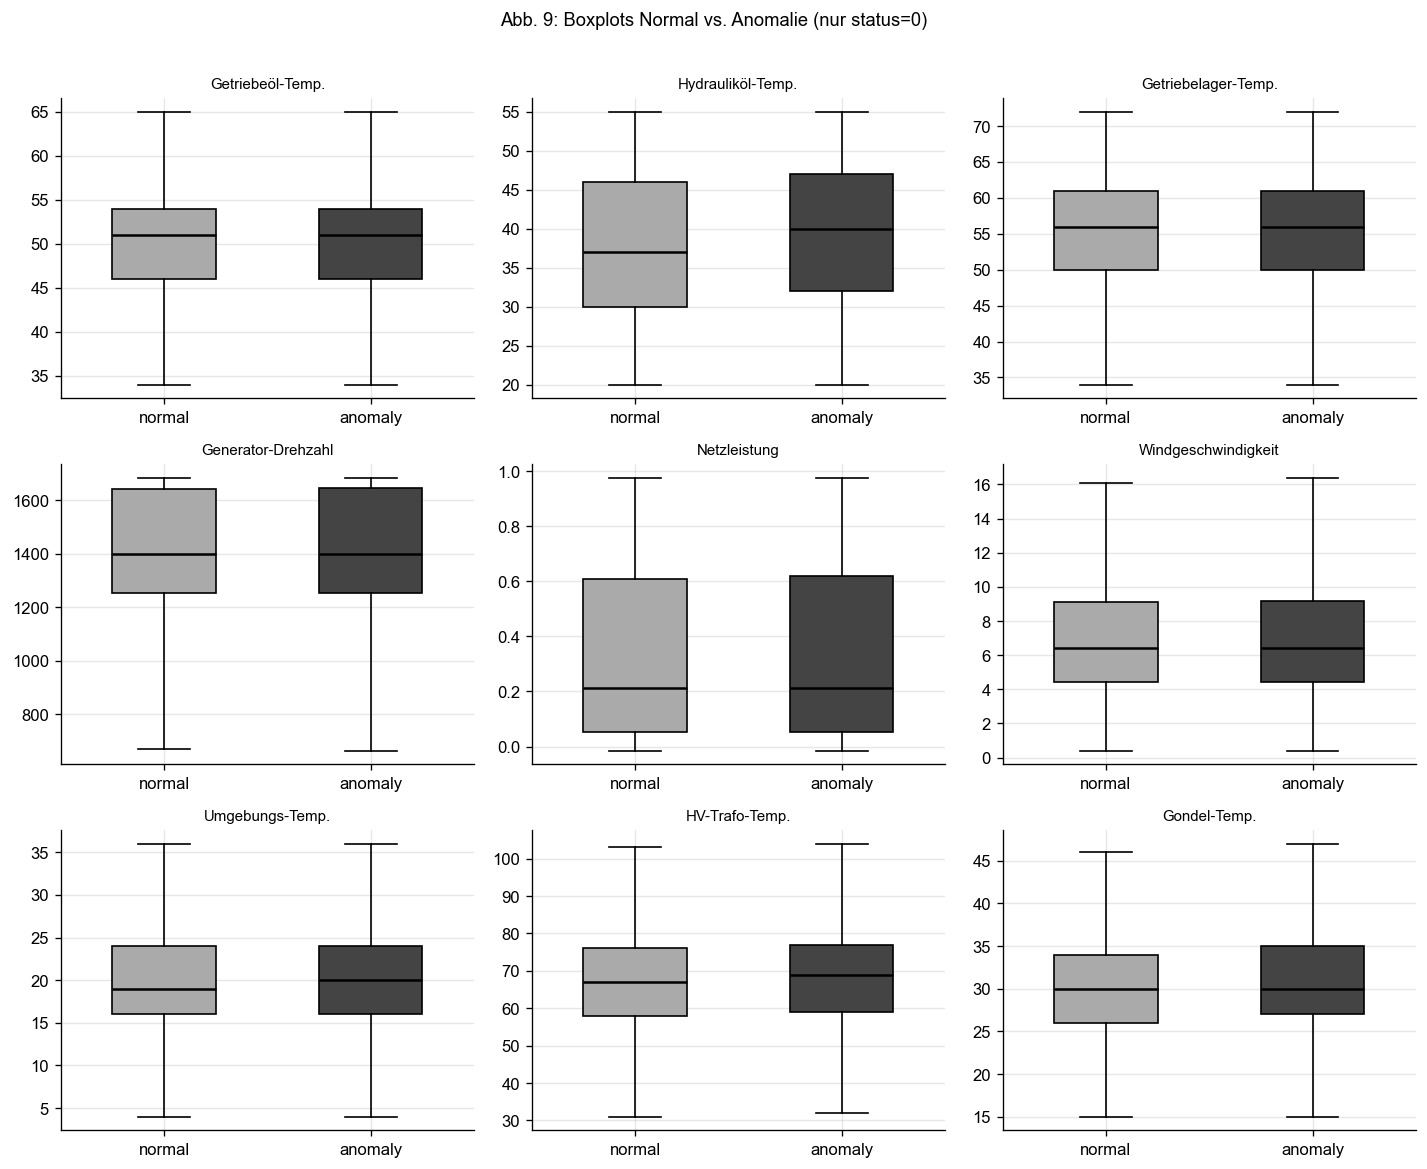

In [ ]:
boxes = {label: {"normal": [], "anomaly": []} for label in key_sensors}
for eid, df in all_dfs.items():
    ev = ev_A[ev_A["event_id"] == eid].iloc[0]
    mask0 = df["status_type_id"] == 0
    cat = "anomaly" if ev["event_label"] == "anomaly" else "normal"
    for label, col in key_sensors.items():
        boxes[label][cat].append(df.loc[mask0, col].dropna().values)

for label in boxes:
    for cat in boxes[label]:
        boxes[label][cat] = (np.concatenate(boxes[label][cat])
                             if boxes[label][cat] else np.array([]))

ncols = 3
nrows = (len(key_sensors) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.2 * nrows))
axes = axes.flatten()
for i, (label, col) in enumerate(key_sensors.items()):
    data = [boxes[label]["normal"], boxes[label]["anomaly"]]
    bp = axes[i].boxplot(data, labels=["normal", "anomaly"], patch_artist=True,
                         widths=0.5, showfliers=False,
                         medianprops=dict(color="black", linewidth=1.5))
    bp["boxes"][0].set_facecolor(COL_N)
    bp["boxes"][1].set_facecolor(COL_A)
    axes[i].set_title(label, fontsize=9)
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
fig.suptitle("Abb. 9: Boxplots Normal vs. Anomalie (nur status=0)", fontsize=11, y=1.01)
fig.tight_layout()
plt.show()

Für den Vergleich von Normal- und Störungsbetrieb wurden nur Zeitstempel im aktiven Normalbetrieb (status_type_id = 0) verwendet. In Abbildung 9 ist ersichtlich, dass Mediane und Interquartilsbereiche bei nahezu allen Sensoren überlappen. Eine minimale Verschiebung zeigt sich bei der Hydrauliköl-Temperatur, deren Median in Anomalie-Dateien tendenziell höher liegt.

**Was bedeutet das?** Auf Einzelzeitpunkt-Ebene kann man Normal- und Fehlerbetrieb praktisch nicht unterscheiden. Die Anomalie-Dateien enthalten überwiegend Normalbetrieb und nur wenige Tage vor dem Ausfall weichen die Werte ab. Genau das ist das stärkste Argument für den Einsatz zeitlicher Modelle (wie LSTM oder Conv-Autoencoder), die den Verlauf über Stunden und Tage betrachten und so schleichende Veränderungen erfassen können, die bei der Betrachtung einzelner Zeitpunkte untergehen.

Mittelwert-Sensoren: 54


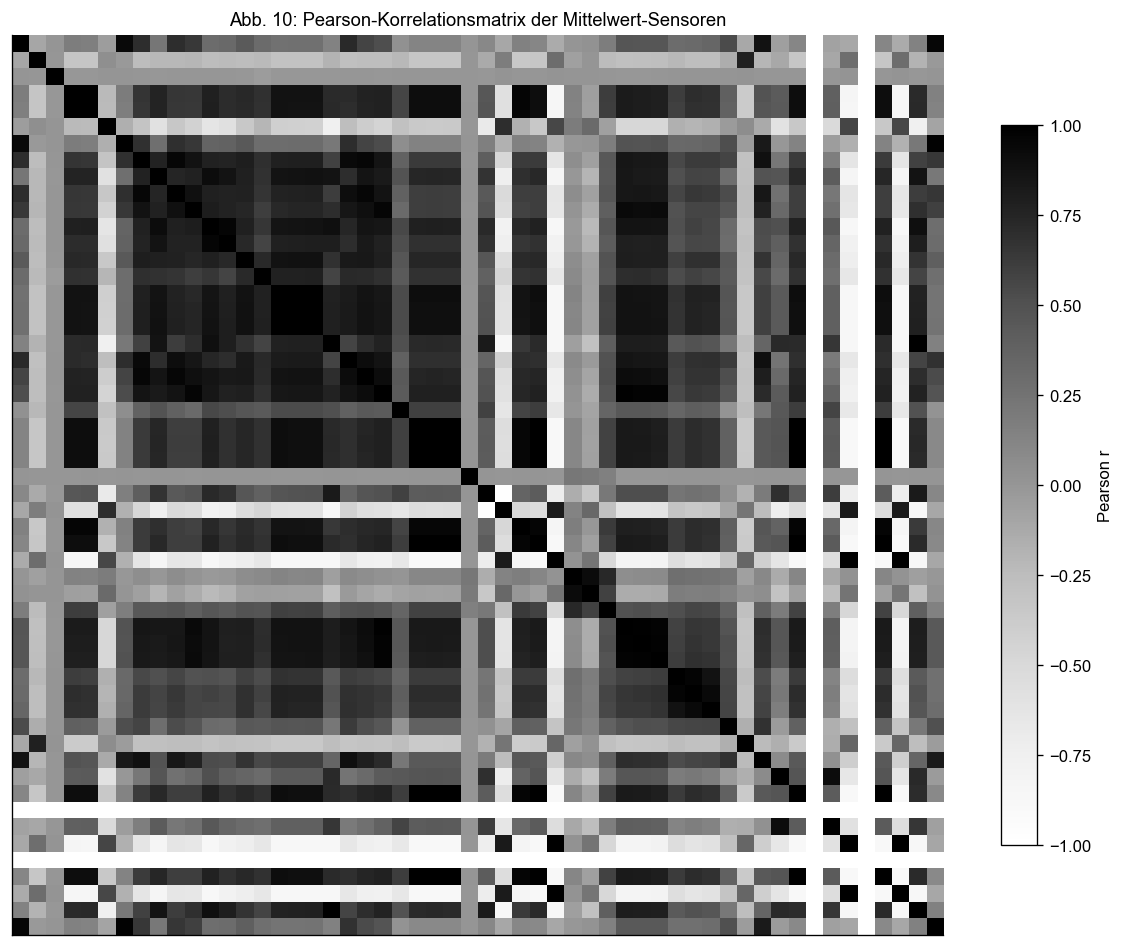


Max. Korrelation mit PrE_Failure (7d): 0.0391

Top-10 Sensoren:
  sensor_21_avg                        r=0.0391
  sensor_9_avg                         r=0.0390
  sensor_10_avg                        r=0.0376
  sensor_36_avg                        r=0.0375
  sensor_37_avg                        r=0.0366
  sensor_19_avg                        r=0.0355
  sensor_7_avg                         r=0.0328
  sensor_0_avg                         r=0.0315
  sensor_35_avg                        r=0.0309
  sensor_53_avg                        r=0.0306


In [ ]:

avg_cols = [c for c in sensor_cols
            if not any(c.endswith(s) for s in ["_min", "_max", "_std", "_sd"])]
print(f"Mittelwert-Sensoren: {len(avg_cols)}")

big_avg = pd.concat([df[avg_cols] for df in all_dfs.values()], ignore_index=True)
corr = big_avg.corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap="Greys", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Abb. 10: Pearson-Korrelationsmatrix der Mittelwert-Sensoren")
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
fig.tight_layout()
plt.show()

lead_hours = 7 * 24
rows_corr = []
for eid, df in all_dfs.items():
    ev = ev_A[ev_A["event_id"] == eid].iloc[0]
    ts = pd.to_datetime(df["time_stamp"])
    label = np.zeros(len(df), dtype=np.int8)
    if ev["event_label"] == "anomaly":
        mask4 = df["status_type_id"] == 4
        if mask4.any():
            first_fail = ts[mask4].min()
            pre_start = first_fail - pd.Timedelta(hours=lead_hours)
            label = ((ts >= pre_start) & (ts < first_fail)).astype(np.int8).values
    sub = df[df["status_type_id"] == NORMAL_STATUS].copy()
    sub["pref"] = label[df["status_type_id"] == NORMAL_STATUS]
    rows_corr.append(sub)

big_pref = pd.concat(rows_corr, ignore_index=True)
corr_pref = big_pref[avg_cols].corrwith(big_pref["pref"]).abs().sort_values(ascending=False)

print(f"\nMax. Korrelation mit PrE_Failure (7d): {corr_pref.iloc[0]:.4f}")
print("\nTop-10 Sensoren:")
for col, val in corr_pref.head(10).items():
    print(f"  {col:35s}  r={val:.4f}")

Die Korrelationsmatrix der Mittelwert-Sensoren zeigt ein komplexes Bild (Abbildung 10). Innerhalb der Temperatur- und Leistungsgruppe bestehen Korrelationen von über 0,9. Für baumbasierte Modelle wie Random Forest oder Isolation Forest ist das unkritisch, da sie mit korrelierten Features umgehen können. Für die Interpretation der Feature Importance bedeutet es allerdings, dass die Relevanz einzelner Sensoren auf mehrere korrelierte Features verteilt und damit unterschätzt werden kann.

Die Korrelation einzelner Features mit einem exemplarisch gewählten 7-Tage-Vorlauffenster liegt maximal bei ungefähr 0,04. Das ist ein sehr geringer Wert und bestätigt eine wichtige Erkenntnis: Kein einzelner Sensor kann allein als Frühwarnung dienen. Eine Anomalie zeigt sich erst im Zusammenspiel mehrerer Sensoren über die Zeit. Das ist genau das, was die zeitlichen Modelle abbilden sollen.

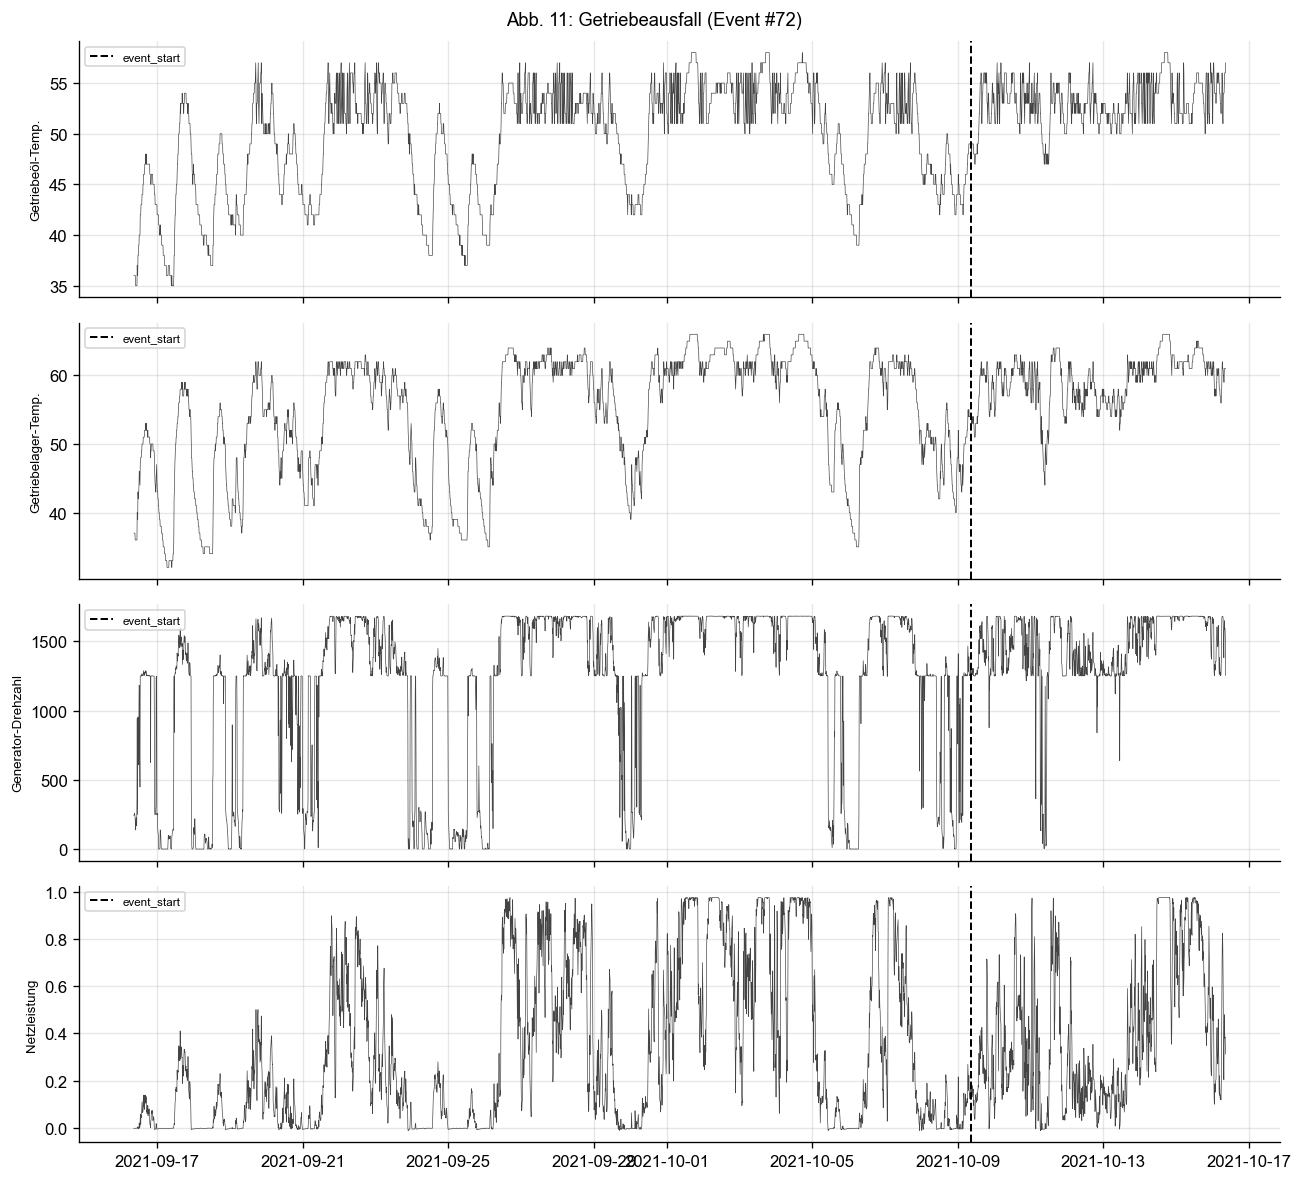

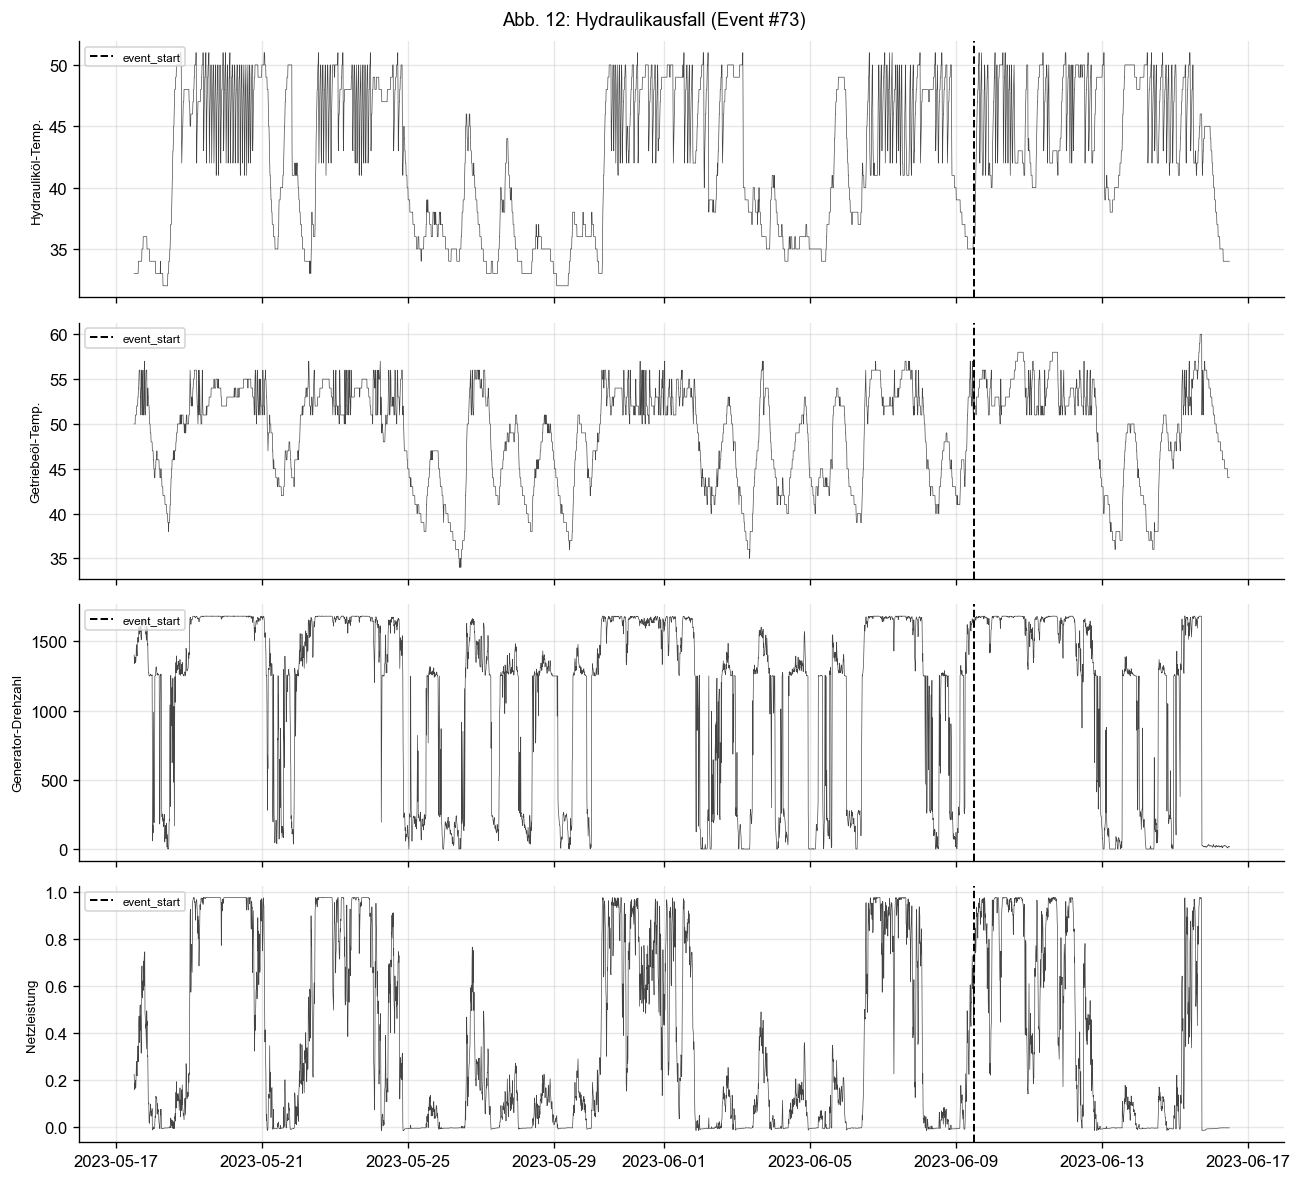

In [ ]:
def plot_event_timeseries(eid, sensors_labels, title, fig_label, days=30):
    ev = ev_A[ev_A["event_id"] == eid].iloc[0]
    df = all_dfs[eid].copy()
    df["time_stamp"] = pd.to_datetime(df["time_stamp"])
    end = ev["event_end"]
    start_plot = end - pd.Timedelta(days=days)
    sub = df[(df["time_stamp"] >= start_plot) & (df["time_stamp"] <= end)]

    n = len(sensors_labels)
    fig, axes = plt.subplots(n, 1, figsize=(11, 2.5 * n), sharex=True)
    if n == 1: axes = [axes]
    for ax, (col, label) in zip(axes, sensors_labels):
        if col and col in sub.columns:
            ax.plot(sub["time_stamp"], sub[col], lw=0.4, color=COL_A)
            ax.set_ylabel(label, fontsize=8)
        else:
            ax.text(0.5, 0.5, f"{col} nicht gefunden", transform=ax.transAxes, ha="center")
        ax.axvline(ev["event_start"], color="black", ls="--", lw=1.2, label="event_start")
        ax.legend(fontsize=7, loc="upper left")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    fig.suptitle(f"{fig_label}: {title} (Event #{eid})", fontsize=11)
    fig.tight_layout()
    plt.show()

gear_eid = 72 if 72 in all_dfs else None
if gear_eid is None:
    ge = anom[anom[desc_col_name].str.contains("gear|getriebe", case=False, na=False)]
    if len(ge): gear_eid = int(ge.iloc[0]["event_id"])

if gear_eid:
    s11 = [(key_sensors.get("Getriebeöl-Temp."), "Getriebeöl-Temp."),
           (key_sensors.get("Getriebelager-Temp."), "Getriebelager-Temp."),
           (key_sensors.get("Generator-Drehzahl"), "Generator-Drehzahl"),
           (key_sensors.get("Netzleistung"), "Netzleistung")]
    s11 = [(c, l) for c, l in s11 if c]
    plot_event_timeseries(gear_eid, s11, "Getriebeausfall", "Abb. 11")
else:
    print("Kein Getriebe-Event gefunden")

hyd_eid = 73 if 73 in all_dfs else None
if hyd_eid is None:
    he = anom[anom[desc_col_name].str.contains("hydraul|hyd", case=False, na=False)]
    if len(he): hyd_eid = int(he.iloc[0]["event_id"])

if hyd_eid:
    s12 = [(key_sensors.get("Hydrauliköl-Temp."), "Hydrauliköl-Temp."),
           (key_sensors.get("Getriebeöl-Temp."), "Getriebeöl-Temp."),
           (key_sensors.get("Generator-Drehzahl"), "Generator-Drehzahl"),
           (key_sensors.get("Netzleistung"), "Netzleistung")]
    s12 = [(c, l) for c, l in s12 if c]
    plot_event_timeseries(hyd_eid, s12, "Hydraulikausfall", "Abb. 12")
else:
    print("Kein Hydraulik-Event gefunden")

Exemplarisch wurden zwei Ausfälle im Zeitverlauf visualisiert: ein Getriebeausfall (Event 72) und ein Hydraulikausfall (Event 73), jeweils mit 30 Tagen Vorlauf.

Getriebeausfall (Abbildung 11): Die Getriebeöl- und Getriebelager-Temperaturen zeigen vor dem markierten `event_start` kein offensichtlich abweichendes Muster. Erst danach stabilisieren sich die Temperaturen auf einem dauerhaft hohen Niveau, während Drehzahl und Leistung einbrechen. Das deutet darauf hin, dass `event_start` nicht den Beginn der Degradation markiert, sondern den Diagnosezeitpunkt — also den Moment, an dem das Problem erkannt und dokumentiert wurde.

Hydraulikausfall (Abbildung 12): Die Hydrauliköl Temperatur liegt bereits Wochen vor `event_start` häufig am oberen Rand des Wertebereichs (ca. 50 °C). Die anderen Sensoren zeigen keinen eindeutigen Zusammenhang, was konsistent damit ist, dass Hydraulikausfälle sich primär im Temperatursensor zeigen.

Beide Beispiele bestätigen eine zentrale Beobachtung: Die Labels markieren den Eingriffszeitpunkt, nicht den tatsächlichen Degradationsbeginn. Genau deshalb verwenden wir im Modellteil die gesamte Prediction-Periode als Anomalie-Label. Ein fixes Vorlaufzeitfenster (z. B. 7 Tage) wäre willkürlich und würde den unbekannten Degradationsbeginn nicht besser abbilden.

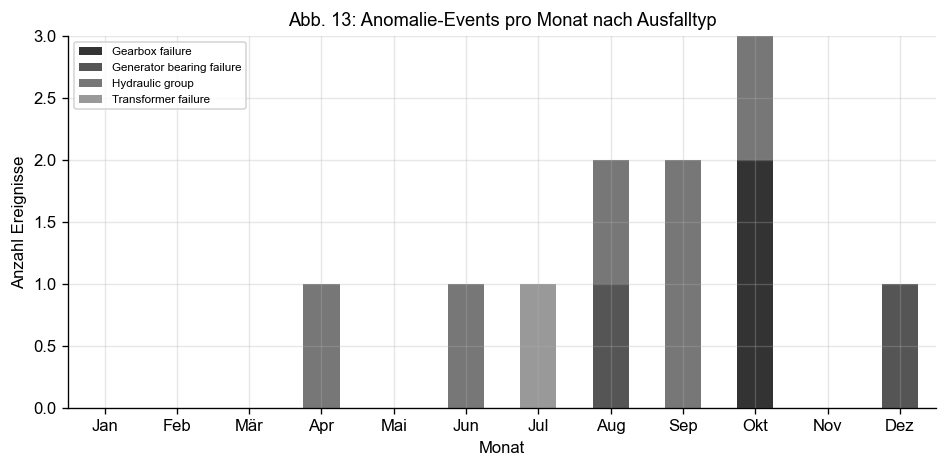

In [ ]:
anom_plot = anom.copy()
anom_plot["month"] = pd.to_datetime(anom_plot["event_start"]).dt.month

ct_month = pd.crosstab(anom_plot["month"], anom_plot[desc_col_name])
ct_month = pd.DataFrame(index=range(1, 13)).join(ct_month).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(8, 4))
greys = ["#333333", "#555555", "#777777", "#999999"]
ct_month.plot.bar(stacked=True, ax=ax, color=greys[:len(ct_month.columns)])
ax.set_xlabel("Monat"); ax.set_ylabel("Anzahl Ereignisse")
ax.set_xticklabels(["Jan","Feb","Mär","Apr","Mai","Jun",
                     "Jul","Aug","Sep","Okt","Nov","Dez"], rotation=0)
ax.set_title("Abb. 13: Anomalie-Events pro Monat nach Ausfalltyp")
ax.legend(fontsize=7, loc="upper left")
fig.tight_layout()
plt.show()

Bei der Betrachtung der elf Anomalie-Ereignisse über den Beobachtungszeitraum (Abbildung 13) zeigt sich eine Häufung in der zweiten Jahreshälfte. Zwischen Januar und Mai tritt nur ein Ereignis auf, ab Juni steigt die Frequenz, und im Oktober wird mit drei Ereignissen der Höhepunkt erreicht. Ein eindeutiger saisonaler Zusammenhang lässt sich aus den Daten jedoch nicht mit Sicherheit ableiten.

### Zusammenfassung der EDA-Erkenntnisse

Die explorative Analyse hat folgende Erkenntnisse geliefert, die direkt in die Modellierungsentscheidungen einfließen:

- **Datenqualität:** Sehr gut (nur 40 NaN-Werte, keine Inf-Werte). Zwei konstante Sensoren werden entfernt.
- **Klassenungleichgewicht:** Extreme Schieflage → Class Weights und F1/ROC-AUC statt Accuracy.
- **Einzelzeitpunkt-Trennung:** Kaum möglich → zeitliche Modelle nötig.
- **Ausfalltypen:** Asymmetrisch verteilt (Hydraulik dominiert) → Binärklassifikation statt Multiclass.
- **Labels:** Markieren den Eingriffszeitpunkt, nicht den Degradationsbeginn → periodenbasierte Labeldefinition (gesamter Prediction-Teil).
- **Korrelation:** Kein einzelner Sensor als Frühwarnung brauchbar → multivariate Modelle nötig.

## 3 · Datenvorverarbeitung

In diesem Abschnitt werden die Rohdaten so aufbereitet, dass die Modelle sie verarbeiten können. Die wichtigsten Schritte:

**Gleitende Fenster:** Die Daten werden nicht zeitpunktweise betrachtet, sondern in Fenstern von 144 Schritten (= 24 Stunden bei 10-Minuten-Auflösung). Die Fenster werden mit einer Schrittweite von 6 (= 1 Stunde) über die Zeitreihe geschoben. Jedes Fenster ist kausal aufgebaut, enthält also nur Werte aus der Vergangenheit, damit kann das Modell in der Praxis nicht "in die Zukunft schauen".

**Fehlende Werte:** Werden durch Fortschreiben des letzten bekannten Werts aufgefüllt (forward/backward fill). Kategoriale Variablen kommen im Datensatz nicht vor. Outlier werden nicht gesondert behandelt, da die semi-supervised Modelle Abweichungen vom Normalverhalten gerade als Anomalie erkennen sollen. Outlier zu entfernen wäre hier kontraproduktiv.

**Trainings-/Testaufteilung:** Nur Normalbetrieb (Status 0) aus dem Trainings-Teil wird zum Lernen verwendet. Die Bewertung erfolgt auf dem gesamten Prediction-Teil. Die Standardisierung (StandardScaler) wird in jedem LOAO-Fold nur auf den Trainingsdaten berechnet, damit kein Wissen aus den Testdaten ins Training fließt.

**Zwei Feature-Repräsentationen:** Die tabellarischen Modelle erhalten pro Fenster sieben Kennzahlen je Sensor (Mittelwert, Standardabweichung, Minimum, Maximum, 10.-, 50.- und 90.-Perzentil). Die zeitlichen Modelle bekommen die rohen Fenster, damit sie den vollständigen Verlauf nutzen können.

Für Windpark B (257 Features) werden die Fenster für den Autoencoder über einen Generator batchweise erzeugt, da sonst der Arbeitsspeicher nicht ausreicht.

In [ ]:
def make_windows(values, window=W, stride=S):
    if len(values) < window:
        return np.empty((0, window, values.shape[1]), dtype=np.float32)
    win = sliding_window_view(values, window, axis=0).transpose(0, 2, 1)[::stride]
    return np.ascontiguousarray(win, dtype=np.float32)

def build_event(farm, ev, window=W, stride=S):
    df = load_event_data(farm, ev["event_id"])
    cols = feature_cols(df)
    df[cols] = df[cols].ffill().bfill()
    tr = df[(df["train_test"] == "train") & (df["status_type_id"] == NORMAL_STATUS)]
    pr = df[df["train_test"] == "prediction"]
    Xtr = make_windows(tr[cols].to_numpy(), window, stride)
    Xpr = make_windows(pr[cols].to_numpy(), window, stride)
    ypr = np.full(len(Xpr), int(ev["event_label"] == "anomaly"), dtype=np.int8)
    return Xtr, Xpr, ypr, cols

def make_loao_folds(farm, n_test_normals=3, seed=0):
    ev = events[events["farm"] == farm]
    anomalies = ev[ev["event_label"] == "anomaly"]["event_id"].tolist()
    normals   = ev[ev["event_label"] == "normal"]["event_id"].tolist()
    rng = np.random.default_rng(seed); norm_cycle = itertools.cycle(rng.permutation(normals))
    folds = []
    for a in anomalies:
        test_normals = [int(next(norm_cycle)) for _ in range(min(n_test_normals, len(normals)))]
        test = [a] + test_normals
        train = [e for e in ev["event_id"] if e not in test]
        folds.append({"test_anomaly": a, "test": test, "train": train})
    return folds

folds = {f: make_loao_folds(f) for f in CONFIG["FARMS"]}
for f in CONFIG["FARMS"]:
    print(f"Farm {f}: {len(folds[f])} Folds")

from sklearn.preprocessing import StandardScaler

def fit_scaler(X):
    return StandardScaler().fit(X.reshape(-1, X.shape[-1]))

def apply_scaler(sc, X):
    shp = X.shape
    return sc.transform(X.reshape(-1, shp[-1])).reshape(shp).astype(np.float32)

Farm A: 11 Folds
Farm B: 6 Folds


## 4 · Semi-supervised tabellarisch (Isolation Forest, One-Class SVM)

### Modellauswahl und Begründung

Beide Modelle passen zum semi-supervised Ansatz, da sie nur Normaldaten zum Training benötigen und keine Anomalie-Labels brauchen.

**Isolation Forest** (200 Bäume): Baut zufällige Entscheidungsbäume auf und misst, wie schnell ein Datenpunkt isoliert wird. Anomalien lassen sich schneller isolieren als normale Datenpunkte, weil sie seltene Merkmalskombinationen haben.

**One-Class SVM** (RBF-Kern): Lernt eine Grenze um die Normaldaten im Feature-Raum. Datenpunkte, die außerhalb dieser Grenze liegen, werden als Anomalie bewertet.

Beide Modelle arbeiten auf den Fenster-Kennzahlen (7 Statistiken × Anzahl Sensoren). Die Entscheidungsschwelle wird aus dem 99-Prozent-Perzentil der Anomalie-Scores auf den Trainings-Normaldaten abgeleitet (nur die obersten 1 % der Trainings-Scores gelten als anomal).

In [17]:
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

STAT_NAMES = ["mean", "std", "min", "max", "q10", "q50", "q90"]

def window_stats(X):
    if len(X) == 0:
        return np.empty((0, X.shape[-1] * len(STAT_NAMES)), dtype=np.float32)
    q10, q50, q90 = np.quantile(X, [0.1, 0.5, 0.9], axis=1)
    return np.concatenate([X.mean(1), X.std(1), X.min(1), X.max(1), q10, q50, q90],
                          axis=1).astype(np.float32)

def collect(farm, ids, part):
    """Statistiken PRO EVENT berechnen, rohe Fenster sofort freigeben (speicherschonend,
    sonst OOM bei Park B mit 257 Features)."""
    Xs, ys, eids = [], [], []
    for eid in ids:
        ev = events.query("farm == @farm and event_id == @eid").iloc[0]
        Xtr, Xpr, ypr, _ = build_event(farm, ev)
        if part == "train":
            Xs.append(window_stats(Xtr))
        else:
            Xs.append(window_stats(Xpr)); ys.append(ypr); eids.append(np.full(len(Xpr), eid))
        del Xtr, Xpr
    if part == "train":
        return np.concatenate(Xs) if Xs else np.empty((0, 1))
    return (np.concatenate(Xs), np.concatenate(ys), np.concatenate(eids))

In [18]:
def run_tabular():
    for farm in CONFIG["FARMS"]:
        res = {"IsoForest": [], "OC-SVM": []}
        for k, fold in enumerate(folds[farm]):
            Ztr = collect(farm, fold["train"], "train")
            Zte, yte, eids = collect(farm, fold["test"], "pred")
            sc = StandardScaler().fit(Ztr)
            Ztr_s, Zte_s = sc.transform(Ztr), sc.transform(Zte)

            iso = IsolationForest(n_estimators=200, random_state=0, n_jobs=-1).fit(Ztr_s)
            res["IsoForest"].append({"scores": -iso.score_samples(Zte_s), "y": yte, "eids": eids,
                                     "thr": float(np.quantile(-iso.score_samples(Ztr_s), 0.99)),
                                     "test_anomaly": fold["test_anomaly"]})
            idx = np.random.default_rng(0).choice(len(Ztr_s), min(3000, len(Ztr_s)), replace=False)
            oc = OneClassSVM(kernel="rbf", gamma="scale", nu=0.05).fit(Ztr_s[idx])
            res["OC-SVM"].append({"scores": -oc.decision_function(Zte_s), "y": yte, "eids": eids,
                                  "thr": float(np.quantile(-oc.decision_function(Ztr_s), 0.99)),
                                  "test_anomaly": fold["test_anomaly"]})
            print(f"Farm {farm} Fold {k+1}/{len(folds[farm])} ✓", end="  ")
        for model in res:
            save_scores(farm, model, res[model])
        print(f"\n-> Farm {farm}: IsoForest & OC-SVM gespeichert")

if CONFIG["RETRAIN"] or not all(scores_exist(f, "IsoForest") for f in CONFIG["FARMS"]):
    run_tabular()
else:
    print("Tabellarische Scores bereits vorhanden (RETRAIN=False) — uebersprungen.")

Tabellarische Scores bereits vorhanden (RETRAIN=False) — uebersprungen.


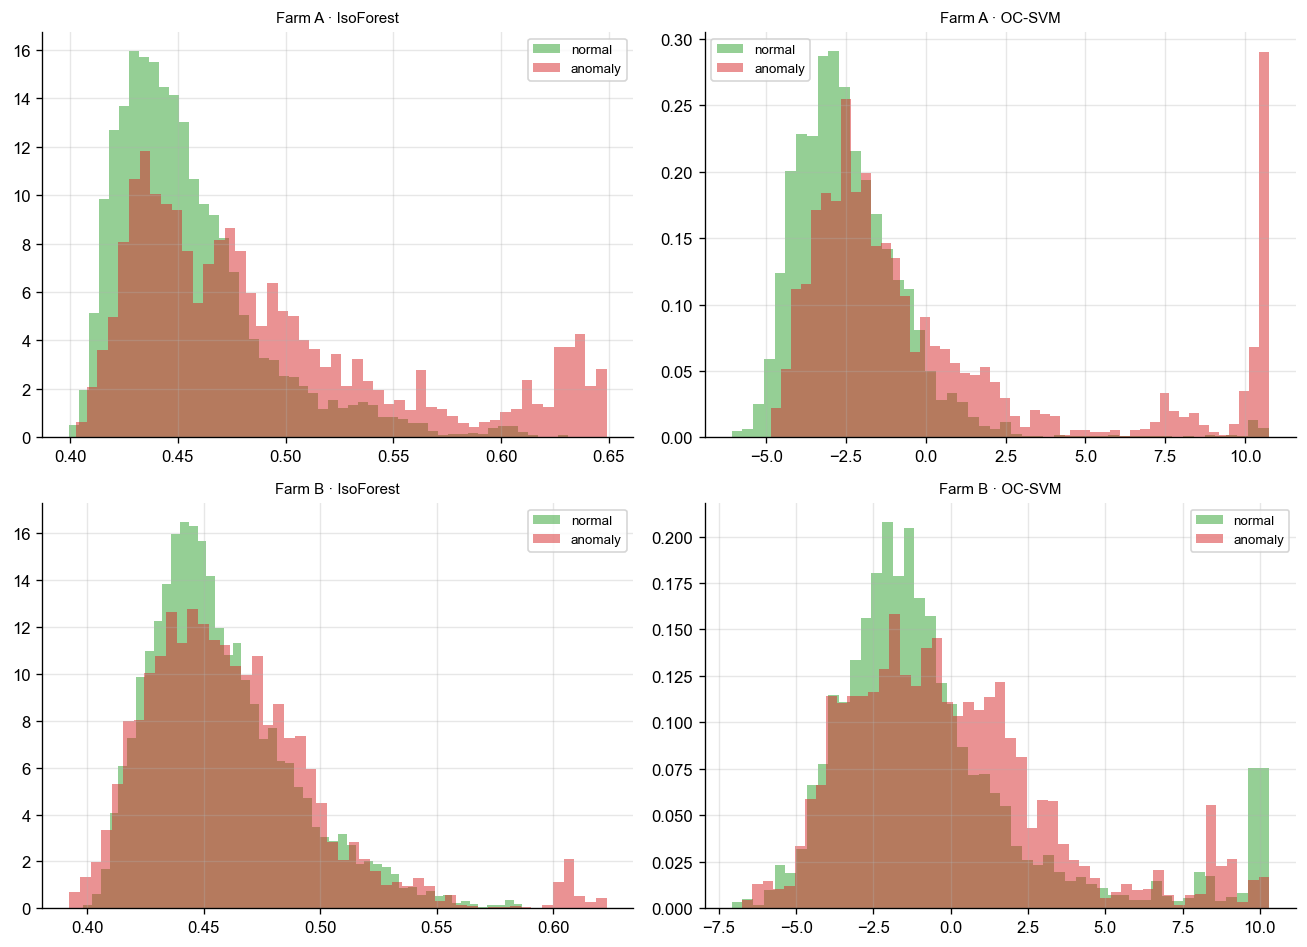

In [19]:
fig, axes = plt.subplots(len(CONFIG["FARMS"]), 2, figsize=(11, 4 * len(CONFIG["FARMS"])))
axes = np.atleast_2d(axes)
for i, farm in enumerate(CONFIG["FARMS"]):
    for j, model in enumerate(["IsoForest", "OC-SVM"]):
        ax = axes[i, j]; per = load_scores(farm, model)
        sc_all = np.concatenate([r["scores"] for r in per]); y_all = np.concatenate([r["y"] for r in per])
        ax.hist(sc_all[y_all == 0], bins=50, density=True, alpha=0.5, color="tab:green", label="normal")
        ax.hist(sc_all[y_all == 1], bins=50, density=True, alpha=0.5, color="tab:red", label="anomaly")
        ax.set_title(f"Farm {farm} · {model}", fontsize=9); ax.legend(fontsize=8)
fig.tight_layout()

### Score-Verteilungen der semi-supervised Modelle

Die Abbildung oben zeigt die Verteilung der Anomalie-Scores getrennt nach Normal- und Anomalie-Events für den Isolation Forest und die One-Class SVM auf beiden Windparks. Im Idealfall wären die grünen (normal) und roten (anomaly) Verteilungen komplett getrennt — das ist hier nicht der Fall, was die grundsätzliche Schwierigkeit der Aufgabe widerspiegelt.

Beim **Isolation Forest** auf Park A zeigt sich eine leichte Verschiebung der Anomalie-Verteilung nach rechts (höhere Scores), was bedeutet, dass das Modell Anomalien tendenziell höher bewertet — allerdings gibt es eine große Überlappungszone. Bei der **One-Class SVM** ist die Trennung etwas deutlicher: Die Anomalie-Events haben häufiger hohe Scores (rechter Rand), während die Normaldaten sich stärker um die Mitte konzentrieren.

Auf **Park B** sind die Verteilungen insgesamt ähnlicher, was mit den niedrigeren ROC-AUC-Werten auf diesem Park übereinstimmt.

## 5 · Semi-supervised temporal (Conv-Autoencoder)

### Modellauswahl und Begründung

Der Conv-Autoencoder ist das dritte semi-supervised Modell, aber im Gegensatz zu Isolation Forest und OC-SVM arbeitet er auf den **rohen Fenstern** statt auf den Statistik-Features. Das Modell lernt, ein normales 24-Stunden-Fenster möglichst genau zu rekonstruieren. Wenn die Turbine gesund ist, gelingt die Rekonstruktion gut (kleiner Fehler). Wenn sich eine Anomalie anbahnt, weichen die Sensormuster vom gelernten Normalverhalten ab, und der Rekonstruktionsfehler steigt.

### Architektur

Der Encoder besteht aus drei Faltungsschichten (Filtergrößen 32, 16, 16; Kernelgröße 7); auf die ersten beiden folgt jeweils ein Max-Pooling (Faktor 2), die dritte Schicht bildet den Flaschenhals. Der Decoder spiegelt die Struktur mit zwei Upsampling-Schichten und schließt mit einer Faltungsschicht ab, die die ursprüngliche Sensoranzahl rekonstruiert. Die Verlustfunktion ist der mittlere quadratische Fehler (MSE).

### Trainingskonfiguration
- **Optimizer:** Adam mit Standard-Lernrate (1e-3) | **Epochen:** 15 | **Batch-Größe:** 256 | **Seed:** 0
- **Schwelle:** 99-Prozent-Perzentil der Trainings-Rekonstruktionsfehler
- Fenster werden über einen **Generator** batchweise erzeugt (speicherschonend für Park B mit 257 Features)

In [20]:
def build_conv_ae(window, n_feat):
    from tensorflow import keras
    from tensorflow.keras import layers
    inp = keras.Input((window, n_feat))
    x = layers.Conv1D(32, 7, padding="same", activation="relu")(inp)
    x = layers.MaxPooling1D(2, padding="same")(x)
    x = layers.Conv1D(16, 7, padding="same", activation="relu")(x)
    x = layers.MaxPooling1D(2, padding="same")(x)
    x = layers.Conv1D(16, 7, padding="same", activation="relu")(x)
    x = layers.UpSampling1D(2)(x)
    x = layers.Conv1D(32, 7, padding="same", activation="relu")(x)
    x = layers.UpSampling1D(2)(x)
    out = layers.Conv1D(n_feat, 7, padding="same")(x)
    m = keras.Model(inp, out); m.compile(optimizer="adam", loss="mse")
    return m

def event_raw(farm, eid, part):
    """Liefert das rohe (ungefensterte) Werte-Array eines Events fuer train- bzw. prediction-Teil."""
    df = load_event_data(farm, eid)
    cols = feature_cols(df); df[cols] = df[cols].ffill().bfill()
    sub = df[(df["train_test"] == "train") & (df["status_type_id"] == NORMAL_STATUS)] if part == "train" \
          else df[df["train_test"] == "prediction"]
    return sub[cols].to_numpy(dtype=np.float32)

def scaler_stats(farm, ids):
    """Mean/Std ueber alle Train-Zeitschritte, streaming akkumuliert (kein Fenster-Stau)."""
    n = 0; s = ss = None
    for eid in ids:
        d = event_raw(farm, eid, "train")
        if len(d) == 0: continue
        if s is None: s, ss = d.sum(0), (d.astype(np.float64)**2).sum(0)
        else: s += d.sum(0); ss += (d.astype(np.float64)**2).sum(0)
        n += len(d)
    mean = (s / n).astype(np.float32)
    std = np.sqrt(np.maximum(ss / n - (s / n)**2, 1e-8)).astype(np.float32)
    return mean, std

def make_window_sequence(raw_lookup, n_feat, mean, std, batch=256, stride=S, window=W, shuffle=True):
    """Baut eine Keras-Sequence zur Laufzeit (TF erst dann verfuegbar). Fenster werden pro Batch
    aus gecachten Event-Arrays geschnitten -> nie alle Fenster gleichzeitig im RAM (loest OOM Park B)."""
    from tensorflow.keras.utils import Sequence

    class WindowSequence(Sequence):
        def __init__(self):
            super().__init__()
            self.raw, self.F, self.mean, self.std = raw_lookup, n_feat, mean, std
            self.bs, self.window, self.shuffle = batch, window, shuffle
            self.index = [(eid, st) for eid, arr in raw_lookup.items()
                          for st in range(0, len(arr) - window + 1, stride)]
            self.index = np.array(self.index) if self.index else np.empty((0, 2), int)
            self.on_epoch_end()
        def __len__(self):
            return int(np.ceil(len(self.index) / self.bs)) if len(self.index) else 0
        def on_epoch_end(self):
            if self.shuffle and len(self.index): np.random.shuffle(self.index)
        def __getitem__(self, i):
            bi = self.index[i*self.bs:(i+1)*self.bs]
            X = np.empty((len(bi), self.window, self.F), dtype=np.float32)
            for j, (eid, st) in enumerate(bi):
                X[j] = self.raw[eid][st:st+self.window]
            X = (X - self.mean) / self.std
            return X, X
    return WindowSequence()

def recon_error_streaming(model, raw, mean, std, batch=256, stride=S, window=W):
    """Scoring fensterweise, ohne alle Fenster zu materialisieren. Gibt (errors, ) zurueck."""
    starts = list(range(0, len(raw) - window + 1, stride))
    errs = []
    for k in range(0, len(starts), batch):
        chunk = starts[k:k+batch]
        Xb = np.empty((len(chunk), window, raw.shape[1]), dtype=np.float32)
        for j, st in enumerate(chunk):
            Xb[j] = raw[st:st+window]
        Xb = (Xb - mean) / std
        rec = model.predict(Xb, batch_size=batch, verbose=0)
        errs.append(((rec - Xb) ** 2).mean(axis=(1, 2)))
    return np.concatenate(errs) if errs else np.empty((0,), np.float32)

In [21]:
def run_conv_ae():
    import tensorflow as tf
    tf.random.set_seed(CONFIG["SEEDS"][0]); np.random.seed(CONFIG["SEEDS"][0])
    for farm in CONFIG["FARMS"]:
        n_feat = len(feature_cols(load_event_data(farm, folds[farm][0]["train"][0])))
        res = []
        for k, fold in enumerate(folds[farm]):
            raw_tr = {eid: event_raw(farm, eid, "train") for eid in fold["train"]}
            mean, std = scaler_stats(farm, fold["train"])
            seq = make_window_sequence(raw_tr, n_feat, mean, std, batch=256)
            ae = build_conv_ae(W, n_feat)
            ae.fit(seq, epochs=CONFIG["AE_EPOCHS"], verbose=0)

            err_tr = np.concatenate([recon_error_streaming(ae, raw_tr[e], mean, std)
                                     for e in fold["train"] if len(raw_tr[e]) >= W])
            thr = float(np.quantile(err_tr, 0.99))
            del raw_tr

            scores, ys, eids = [], [], []
            for eid in fold["test"]:
                ev = events.query("farm == @farm and event_id == @eid").iloc[0]
                raw_pr = event_raw(farm, eid, "prediction")
                e = recon_error_streaming(ae, raw_pr, mean, std)
                scores.append(e); ys.append(np.full(len(e), int(ev["event_label"] == "anomaly"), np.int8))
                eids.append(np.full(len(e), eid))
            res.append({"scores": np.concatenate(scores), "y": np.concatenate(ys),
                        "eids": np.concatenate(eids), "thr": thr, "test_anomaly": fold["test_anomaly"]})
            print(f"Farm {farm} Fold {k+1}/{len(folds[farm])} ✓", end="  ")
        save_scores(farm, "ConvAE", res)
        print(f"\n-> Farm {farm}: ConvAE gespeichert")

if CONFIG["RETRAIN"] or not all(scores_exist(f, "ConvAE") for f in CONFIG["FARMS"]):
    run_conv_ae()
else:
    print("ConvAE-Scores bereits vorhanden (RETRAIN=False) — uebersprungen.")

ConvAE-Scores bereits vorhanden (RETRAIN=False) — uebersprungen.


## 6 · Supervised mit Pseudo-Labels (RF, LightGBM, 1D-CNN, LSTM)

### Begründung und Pseudo-Label-Ansatz

Der CARE-Datensatz bietet im Trainings-Teil nur Normalbetrieb — es gibt keine gelabelten Anomalien zum Trainieren eines supervised Modells. Um trotzdem einen supervised Vergleich aufzubauen, werden **Pseudo-Labels** erzeugt: Prediction-Fenster eines Anomalie-Events gelten als positiv (= Anomalie), Normalbetrieb-Fenster als negativ (= normal).

**Warum machen wir das?** Der semi-supervised Ansatz ist paper-treu (so wie im CARE-Paper vorgesehen). Der supervised Vergleich erlaubt es, die Forschungsfrage auch aus einer anderen Perspektive zu beantworten: Können überwachte Modelle mit expliziten Anomalie-Beispielen besser lernen als Modelle, die nur den Normalbetrieb kennen?

**Wichtig:** Die Pseudo-Label-Annahme (der gesamte Prediction-Teil = Anomalie) ist eine Vereinfachung. In Wirklichkeit enthält der Prediction-Teil vermutlich auch Phasen mit noch normalem Betrieb. Diese Unschärfe wird im Fazit als Limitation diskutiert.

### Architekturen

- **Random Forest:** 300 Bäume, `class_weight="balanced"`, Seed 0
- **LightGBM:** 300 Bäume, `class_weight="balanced"`, Seed 0
- **1D-CNN:** Conv1D(32) → MaxPooling → Conv1D(64) → GlobalMaxPooling → Dense(32) → Dropout(0,3) → Dense(1, Sigmoid). Loss: Binary Crossentropy.
- **LSTM:** LSTM(32) → Dense(16) → Dropout(0,3) → Dense(1, Sigmoid). Loss: Binary Crossentropy.

### Trainingskonfiguration
- **Optimizer (DL):** Adam mit Standard-Lernrate (1e-3) | **Epochen:** 15 | **Batch-Größe:** 256
- **Overfitting-Schutz:** Dropout (0,3) und Class Weights
- **Entscheidungsschwelle:** fest bei 0,5
- **Validierung:** dieselben LOAO-Folds wie semi-supervised

Die Baumanzahl (200 bzw. 300) wurde konservativ hoch gewählt, da die LOAO-Folds zu wenig Daten für eine separate Hyperparameter-Suche lassen. Dropout (0,3) und Class Weights dienen als Regularisierung anstelle einer Validierungs-basierten Early Stopping, da die geringe Anzahl positiver Beispiele eine aussagekräftige Validierungsmetrik innerhalb eines Folds erschwert.

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score
import lightgbm as lgb

def build_supervised_fold_tabular(farm, fold):
    """Train: Normalbetrieb-Fenster (alle train-events, Label 0) + pred-Fenster der ANOMALIE-train-events (Label 1).
    Test: pred-Fenster der test-events, Label = event_label. Alles als Statistik-Features."""
    Xn, Xp = [], []
    for eid in fold["train"]:
        ev = events.query("farm == @farm and event_id == @eid").iloc[0]
        Xtr, Xpr, _, _ = build_event(farm, ev)
        Xn.append(window_stats(Xtr))
        if ev["event_label"] == "anomaly":
            Xp.append(window_stats(Xpr))
        del Xtr, Xpr
    Xtr_f = np.vstack(Xn + Xp)
    ytr_f = np.concatenate([np.zeros(sum(len(a) for a in Xn), np.int8),
                            np.ones(sum(len(a) for a in Xp), np.int8)])
    Xs, ys, eids = [], [], []
    for eid in fold["test"]:
        ev = events.query("farm == @farm and event_id == @eid").iloc[0]
        _, Xpr, ypr, _ = build_event(farm, ev)
        Xs.append(window_stats(Xpr)); ys.append(ypr); eids.append(np.full(len(Xpr), eid))
    return Xtr_f, ytr_f, np.vstack(Xs), np.concatenate(ys), np.concatenate(eids)

def run_supervised_tabular():
    for farm in CONFIG["FARMS"]:
        res = {"RF": [], "LightGBM": []}
        for k, fold in enumerate(folds[farm]):
            Xtr, ytr, Xte, yte, eids = build_supervised_fold_tabular(farm, fold)
            sc = StandardScaler().fit(Xtr); Ztr, Zte = sc.transform(Xtr), sc.transform(Xte)
            rf = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                        n_jobs=-1, random_state=0).fit(Ztr, ytr)
            gbm = lgb.LGBMClassifier(n_estimators=300, class_weight="balanced",
                                     verbose=-1, random_state=0).fit(Ztr, ytr)
            for name, model in [("RF", rf), ("LightGBM", gbm)]:
                p = model.predict_proba(Zte)[:, 1]
                res[name].append({"scores": p.astype(np.float32), "y": yte, "eids": eids,
                                  "thr": 0.5, "test_anomaly": fold["test_anomaly"]})
            print(f"Farm {farm} Fold {k+1}/{len(folds[farm])} ✓", end="  ")
        for name in res: save_scores(farm, name, res[name])
        print(f"\n-> Farm {farm}: RF & LightGBM gespeichert")

if CONFIG["RETRAIN"] or not all(scores_exist(f, "RF") for f in CONFIG["FARMS"]):
    run_supervised_tabular()
else:
    print("Supervised tabellarische Scores vorhanden (RETRAIN=False) — uebersprungen.")

Supervised tabellarische Scores vorhanden (RETRAIN=False) — uebersprungen.


In [ ]:
def build_cnn_clf(window, n_feat):
    from tensorflow import keras
    from tensorflow.keras import layers
    m = keras.Sequential([keras.Input((window, n_feat)),
        layers.Conv1D(32, 7, padding="same", activation="relu"), layers.MaxPooling1D(2),
        layers.Conv1D(64, 7, padding="same", activation="relu"), layers.GlobalMaxPooling1D(),
        layers.Dense(32, activation="relu"), layers.Dropout(0.3), layers.Dense(1, activation="sigmoid")])
    m.compile("adam", "binary_crossentropy", metrics=["AUC"]); return m

def build_lstm_clf(window, n_feat):
    from tensorflow import keras
    from tensorflow.keras import layers
    m = keras.Sequential([keras.Input((window, n_feat)),
        layers.LSTM(32), layers.Dense(16, activation="relu"), layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")])
    m.compile("adam", "binary_crossentropy", metrics=["AUC"]); return m

def predict_event_clf(model, raw, mean, std, batch=256, stride=S, window=W):
    starts = list(range(0, len(raw) - window + 1, stride)); out = []
    for k in range(0, len(starts), batch):
        chunk = starts[k:k+batch]
        Xb = np.empty((len(chunk), window, raw.shape[1]), dtype=np.float32)
        for j, st in enumerate(chunk): Xb[j] = raw[st:st+window]
        Xb = (Xb - mean) / std
        out.append(model.predict(Xb, batch_size=batch, verbose=0).ravel())
    return np.concatenate(out) if out else np.empty((0,), np.float32)

def run_supervised_temporal():
    import tensorflow as tf
    from tensorflow.keras.utils import Sequence
    tf.random.set_seed(CONFIG["SEEDS"][0]); np.random.seed(CONFIG["SEEDS"][0])

    for farm in CONFIG["FARMS"]:
        n_feat = len(feature_cols(load_event_data(farm, folds[farm][0]["train"][0])))
        res = {"CNN": [], "LSTM": []}
        for k, fold in enumerate(folds[farm]):
            store, samples = {}, []
            for eid in fold["train"]:
                ev = events.query("farm == @farm and event_id == @eid").iloc[0]
                kneg = f"{eid}_train"; store[kneg] = event_raw(farm, eid, "train")
                for st in range(0, len(store[kneg]) - W + 1, S):
                    samples.append((kneg, st, 0))
                if ev["event_label"] == "anomaly":
                    kpos = f"{eid}_pred"; store[kpos] = event_raw(farm, eid, "prediction")
                    for st in range(0, len(store[kpos]) - W + 1, S):
                        samples.append((kpos, st, 1))
            mean, std = scaler_stats(farm, fold["train"])
            n_pos = sum(1 for s in samples if s[2] == 1); n_neg = len(samples) - n_pos
            cw = {0: 1.0, 1: float(n_neg / max(1, n_pos))}
            samples = np.array(samples, dtype=object)

            class LabSeq(Sequence):
                def __init__(self, bs=256):
                    super().__init__(); self.bs = bs; self.s = samples.copy(); np.random.shuffle(self.s)
                def __len__(self): return int(np.ceil(len(self.s) / self.bs))
                def on_epoch_end(self): np.random.shuffle(self.s)
                def __getitem__(self, i):
                    b = self.s[i*self.bs:(i+1)*self.bs]
                    X = np.empty((len(b), W, n_feat), dtype=np.float32)
                    y = np.empty(len(b), dtype=np.float32)
                    for j, (key, st, lab) in enumerate(b):
                        X[j] = store[key][st:st+W]; y[j] = lab
                    return (X - mean) / std, y

            for name, builder in [("CNN", build_cnn_clf), ("LSTM", build_lstm_clf)]:
                model = builder(W, n_feat)
                model.fit(LabSeq(), epochs=CONFIG["AE_EPOCHS"], class_weight=cw, verbose=0)
                scores, ys, eids = [], [], []
                for eid in fold["test"]:
                    ev = events.query("farm == @farm and event_id == @eid").iloc[0]
                    raw_pr = event_raw(farm, eid, "prediction")
                    p = predict_event_clf(model, raw_pr, mean, std)
                    scores.append(p); ys.append(np.full(len(p), int(ev["event_label"]=="anomaly"), np.int8))
                    eids.append(np.full(len(p), eid))
                res[name].append({"scores": np.concatenate(scores), "y": np.concatenate(ys),
                                  "eids": np.concatenate(eids), "thr": 0.5, "test_anomaly": fold["test_anomaly"]})
            del store
            print(f"Farm {farm} Fold {k+1}/{len(folds[farm])} ✓", end="  ")
        for name in res: save_scores(farm, name, res[name])
        print(f"\n-> Farm {farm}: CNN & LSTM gespeichert")

if CONFIG["RETRAIN"] or not all(scores_exist(f, "CNN") for f in CONFIG["FARMS"]):
    run_supervised_temporal()
else:
    print("Supervised temporale Scores vorhanden (RETRAIN=False) — uebersprungen.")

Supervised temporale Scores vorhanden (RETRAIN=False) — uebersprungen.


Um den Trainingsprozess der neuronalen Netze nachvollziehbar zu machen, wird der Verlauf von Loss und Metrik exemplarisch für einen LOAO-Fold von Windpark A dargestellt — einmal für den semi-supervised Conv-Autoencoder (Rekonstruktions-MSE) und einmal für den supervised 1D-CNN-Klassifikator (Binary Crossentropy und ROC-AUC). Trainings- und Validierungskurve werden getrennt geplottet, um Overfitting sichtbar zu machen.

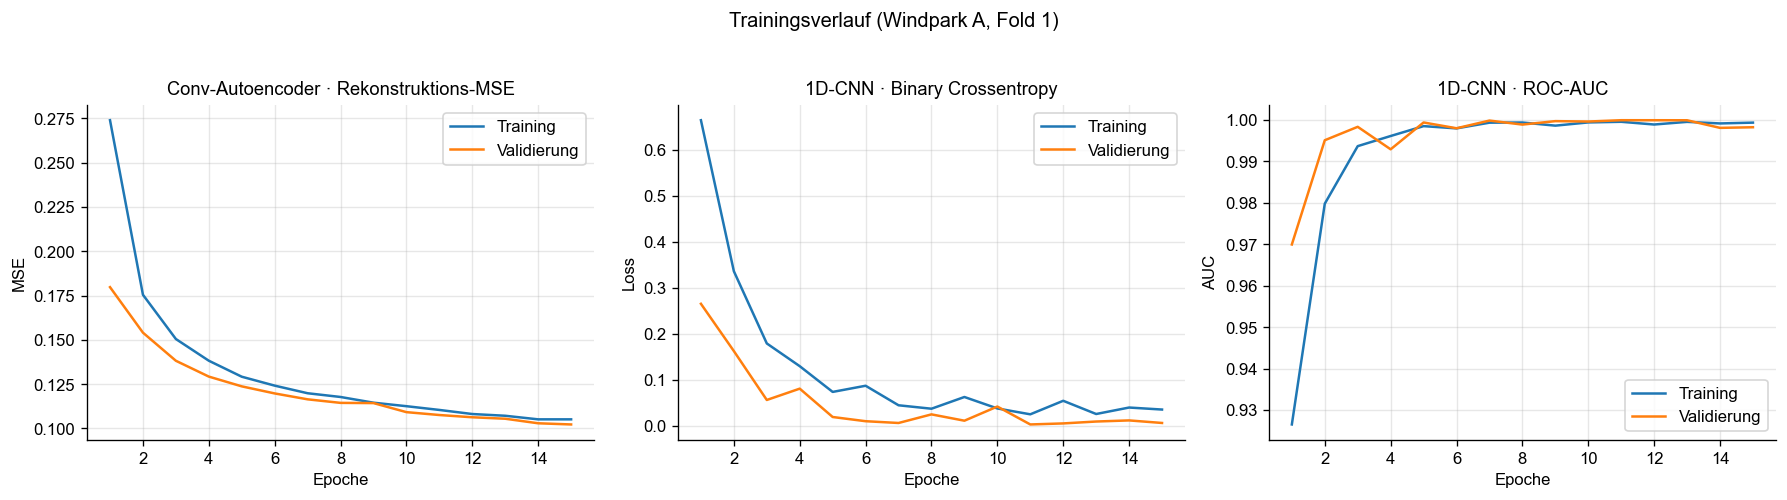

In [24]:
SHOW_TRAINING_CURVES = True

if SHOW_TRAINING_CURVES:
    try:
        import tensorflow as tf
        from tensorflow.keras.utils import Sequence
        tf.random.set_seed(CONFIG["SEEDS"][0]); np.random.seed(CONFIG["SEEDS"][0])

        curve_farm = "A"
        fold = folds[curve_farm][0]
        train_ids = fold["train"]
        n_feat = len(feature_cols(load_event_data(curve_farm, train_ids[0])))

        val_ids_ae, fit_ids_ae = train_ids[-2:], train_ids[:-2]
        mean_ae, std_ae = scaler_stats(curve_farm, fit_ids_ae)
        raw_fit = {e: event_raw(curve_farm, e, "train") for e in fit_ids_ae}
        raw_val = {e: event_raw(curve_farm, e, "train") for e in val_ids_ae}
        seq_fit = make_window_sequence(raw_fit, n_feat, mean_ae, std_ae, batch=256, shuffle=True)
        seq_val = make_window_sequence(raw_val, n_feat, mean_ae, std_ae, batch=256, shuffle=False)
        ae = build_conv_ae(W, n_feat)
        hist_ae = ae.fit(seq_fit, validation_data=seq_val,
                         epochs=CONFIG["AE_EPOCHS"], verbose=0)

        mean_cnn, std_cnn = scaler_stats(curve_farm, train_ids)
        store, idx = {}, []
        for eid in train_ids:
            ev = events.query("farm == @curve_farm and event_id == @eid").iloc[0]
            kn = f"{eid}_train"; store[kn] = event_raw(curve_farm, eid, "train")
            idx += [(kn, st, 0) for st in range(0, len(store[kn]) - W + 1, S)]
            if ev["event_label"] == "anomaly":
                kp = f"{eid}_pred"; store[kp] = event_raw(curve_farm, eid, "prediction")
                idx += [(kp, st, 1) for st in range(0, len(store[kp]) - W + 1, S)]
        rng = np.random.default_rng(0); rng.shuffle(idx)
        n_val = max(1, int(0.1 * len(idx)))
        val_idx, fit_idx = idx[:n_val], idx[n_val:]
        n_pos = sum(1 for _, _, l in fit_idx if l == 1); n_neg = len(fit_idx) - n_pos
        cw = {0: 1.0, 1: float(n_neg / max(1, n_pos))}

        class LabeledSeq(Sequence):
            def __init__(self, index, shuffle=True, bs=256):
                super().__init__(); self.index = list(index); self.shuffle = shuffle; self.bs = bs
                self.on_epoch_end()
            def __len__(self): return int(np.ceil(len(self.index) / self.bs))
            def on_epoch_end(self):
                if self.shuffle: np.random.shuffle(self.index)
            def __getitem__(self, i):
                b = self.index[i*self.bs:(i+1)*self.bs]
                X = np.empty((len(b), W, n_feat), np.float32); y = np.empty(len(b), np.float32)
                for j, (key, st, lab) in enumerate(b):
                    X[j] = store[key][st:st+W]; y[j] = lab
                return (X - mean_cnn) / std_cnn, y

        cnn = build_cnn_clf(W, n_feat)
        hist_cnn = cnn.fit(LabeledSeq(fit_idx, shuffle=True),
                           validation_data=LabeledSeq(val_idx, shuffle=False),
                           epochs=CONFIG["AE_EPOCHS"], class_weight=cw, verbose=0)

        auc_key = next((k for k in hist_cnn.history if "auc" in k.lower() and not k.startswith("val")), None)
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        ep = range(1, CONFIG["AE_EPOCHS"] + 1)

        axes[0].plot(ep, hist_ae.history["loss"], label="Training")
        axes[0].plot(ep, hist_ae.history["val_loss"], label="Validierung")
        axes[0].set_title("Conv-Autoencoder · Rekonstruktions-MSE")
        axes[0].set_xlabel("Epoche"); axes[0].set_ylabel("MSE"); axes[0].legend()

        axes[1].plot(ep, hist_cnn.history["loss"], label="Training")
        axes[1].plot(ep, hist_cnn.history["val_loss"], label="Validierung")
        axes[1].set_title("1D-CNN · Binary Crossentropy")
        axes[1].set_xlabel("Epoche"); axes[1].set_ylabel("Loss"); axes[1].legend()

        if auc_key:
            axes[2].plot(ep, hist_cnn.history[auc_key], label="Training")
            axes[2].plot(ep, hist_cnn.history[f"val_{auc_key}"], label="Validierung")
            axes[2].set_title("1D-CNN · ROC-AUC"); axes[2].set_xlabel("Epoche")
            axes[2].set_ylabel("AUC"); axes[2].legend()
        fig.suptitle(f"Trainingsverlauf (Windpark {curve_farm}, Fold 1)", y=1.03)
        fig.tight_layout(); plt.show()
    except ImportError:
        print("TensorFlow nicht verfuegbar — Trainingskurven uebersprungen (nur fuer DL-Neuberechnung noetig).")

Beim Conv-Autoencoder (links) sinkt der Rekonstruktions-MSE auf den Trainingsdaten von anfangs rund 0,275 zügig ab und nähert sich ab etwa Epoche 8 einem Plateau bei ca. 0,105. Die Validierungskurve folgt dem Verlauf eng und liegt sogar leicht unterhalb der Trainingskurve. Das ist das erwartete Verhalten eines Modells, das ein stabiles Bild des Normalbetriebs lernt. Training und Validierung konvergieren, ein Auseinanderlaufen der Kurven (das typische Zeichen für Overfitting) tritt nicht auf. Dass die Validierung etwas niedriger liegt, ist kein Widerspruch: Das Validierungsset enthält nur zwei Events und kann zufällig leichter zu rekonstruierende Muster enthalten.

Beim 1D-CNN-Klassifikator (Mitte) fällt der Trainings-Loss von rund 0,65 über die 15 Epochen auf nahe 0,02. Der Validierungs-Loss sinkt schneller und erreicht bereits ab Epoche 4 Werte nahe null. Dass der Trainings-Loss dauerhaft über dem Validierungs-Loss liegt, ist hier kein Fehler, sondern eine Folge der Class Weights: Keras gewichtet die Fehler auf der seltenen Anomalie-Klasse im Training deutlich höher, was den Trainings-Loss nach oben treibt. Auf die Validierung werden die Class Weights nicht angewendet, daher erscheint dieser Loss niedriger.

Die ROC-AUC des 1D-CNN (rechts) steigt auf den Trainingsdaten von rund 0,93 auf nahezu 1,0 und stabilisiert sich dort ab Epoche 6. Die Validierungs-AUC liegt ebenfalls über 0,99 und schwankt nur minimal. Das zeigt, dass das Modell innerhalb des Folds die Trainings- und Validierungsfenster fast perfekt trennen kann. Das klingt zunächst sehr gut, spiegelt sich aber nicht in den finalen LOAO-Ergebnissen wider — dort liegen die supervised Modelle deutlich niedriger. Der Grund: Innerhalb eines Folds sieht das Modell Anomalie-Fenster aus denselben Events, auf die es trainiert wurde. Die eigentliche Herausforderung liegt darin, ein unbekanntes nomalie-Event zu erkennen, das im LOAO-Test-Fold herausgehalten wird. Die hohen Werte hier zeigen also eher, dass das Modell die bekannten Muster gut auswendig lernt, als dass es gut generalisiert.

## 7 · Evaluation und Ergebnisse

### Metriken

Die Bewertung erfolgt über die gepoolten Vorhersagen aller LOAO-Durchläufe (Pooled Predictions). Dabei werden zwei Metriken verwendet:

- **ROC-AUC:** Bewertet die Rangfolge der Anomalie-Scores schwellenunabhängig. Ein Wert von 0,5 entspricht Zufall, 1,0 wäre perfekt. Der Vorteil: Die Metrik ist unabhängig von der gewählten Entscheidungsschwelle und zeigt, ob das Modell grundsätzlich in der Lage ist, Anomalien höher zu bewerten als Normalverhalten.
- **F1-Score:** Bewertet bei der konkreten Entscheidungsschwelle, wie gut Treffer und Fehlalarme ausbalanciert sind. Ein Wert nahe 0 bedeutet, dass das Modell bei der gewählten Schwelle praktisch keine brauchbaren Vorhersagen liefert.

### Ergebnistabelle

In [25]:
from sklearn.metrics import roc_auc_score, f1_score

SEMI = ["IsoForest", "OC-SVM", "ConvAE"]
SUP  = ["RF", "LightGBM", "CNN", "LSTM"]
MODELS = SEMI + SUP
rows = []
for farm in CONFIG["FARMS"]:
    for model in MODELS:
        if not scores_exist(farm, model):
            continue
        per = load_scores(farm, model)
        sc_all = np.concatenate([r["scores"] for r in per])
        y_all  = np.concatenate([r["y"] for r in per])
        pred   = np.concatenate([(r["scores"] > r["thr"]).astype(int) for r in per])
        auc = roc_auc_score(y_all, sc_all) if len(np.unique(y_all)) > 1 else np.nan
        f1  = f1_score(y_all, pred, zero_division=0)
        rows.append({"farm": farm, "paradigm": "semi" if model in SEMI else "supervised",
                     "model": model, "ROC_AUC": round(auc, 3),
                     "F1@thr": round(f1, 3), "n_windows": len(y_all)})
results_table = pd.DataFrame(rows)
display(results_table)

,farm,paradigm,model,ROC_AUC,F1@thr,n_windows
0,A,semi,IsoForest,0.675,0.230,16888
1,A,semi,OC-SVM,0.695,0.283,16888
2,A,semi,ConvAE,0.627,0.199,16888
3,A,supervised,RF,0.479,0.014,16888
4,A,supervised,LightGBM,0.436,0.127,16888
5,A,supervised,CNN,0.416,0.212,16888
6,A,supervised,LSTM,0.411,0.229,16888
7,B,semi,IsoForest,0.526,0.087,17100
8,B,semi,OC-SVM,0.553,0.210,17100
9,B,semi,ConvAE,0.599,0.392,17100


### Interpretation der Ergebnisse

Das Ergebnis zeigt ein klares Bild: **Auf Park A schneiden die semi-supervised Modelle deutlich besser ab als die supervised Modelle.** Die One-Class SVM erzielt mit einer ROC-AUC von 0,695 das beste Ergebnis, gefolgt vom Isolation Forest (0,675) und dem Conv-Autoencoder (0,627). Alle drei liegen über dem Zufallsniveau von 0,5.

Die supervised Modelle hingegen liegen auf Park A alle **unter 0,5** — also schlechter als Zufall. Das bedeutet: Die Pseudo-Labels führen hier nicht zu brauchbaren Mustern. Der Grund ist vermutlich, dass die Anomalie-Verläufe in Park A mit ca. 10 Tagen relativ kurz sind und der Prediction-Zeitraum viel Normalbetrieb enthält, der fälschlich als Anomalie gelabelt wird. Die Modelle lernen dadurch verrauschte, widersprüchliche Muster.

Auf **Park B** zeigt sich ein anderes Bild: Die Werte liegen insgesamt näher beieinander. Der Conv-Autoencoder erreicht mit 0,599 den besten semi-supervised Wert. Bei den supervised Modellen liegt der Random Forest (0,550) knapp vorn. Die längeren Anomalie-Verläufe in Park B (bis zu 61 Tage) machen die Pseudo-Labels dort etwas tauglicher.

**Antwort auf die Forschungsfrage:** Die explizite Modellierung der Zeitstruktur zeigt keinen durchgängigen Vorteil. Der Conv-Autoencoder (zeitlich) liegt auf beiden Parks hinter den tabellarischen semi-supervised Modellen. Die Zeitstruktur hilft also nicht automatisch — entscheidend ist vor allem das Lernparadigma (semi-supervised schlägt supervised auf Park A klar) und die Qualität der Labels.

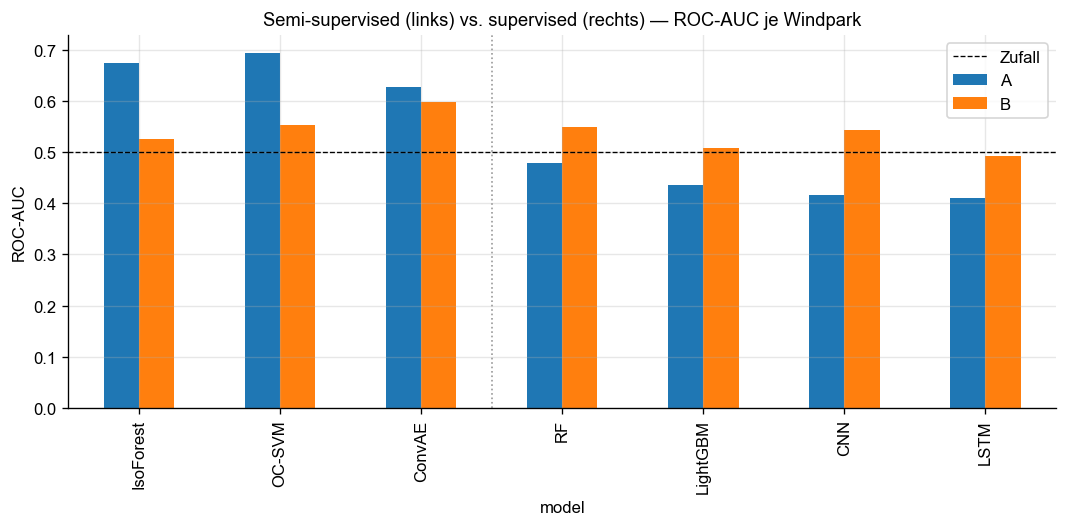

In [26]:
order = [m for m in (SEMI + SUP) if m in results_table["model"].values]
fig, ax = plt.subplots(figsize=(9, 4.5))
piv = results_table.pivot(index="model", columns="farm", values="ROC_AUC").reindex(order)
piv.plot.bar(ax=ax); ax.axhline(0.5, color="k", ls="--", lw=0.8, label="Zufall")
ax.axvline(len(SEMI) - 0.5, color="0.6", ls=":", lw=1)
ax.set_ylabel("ROC-AUC"); ax.set_title("Semi-supervised (links) vs. supervised (rechts) — ROC-AUC je Windpark")
ax.legend(); fig.tight_layout()


Das Balkendiagramm oben zeigt die ROC-AUC aller sieben Modelle für beide Windparks. Links der gestrichelten Trennlinie stehen die semi-supervised Modelle, rechts die supervised. Die horizontale Linie bei 0,5 markiert das Zufallsniveau.

Auf Park A (blau) ist sofort erkennbar, dass die drei semi-supervised Balken über der Zufallslinie liegen, während alle vier supervised Balken darunter bleiben. Auf Park B (orange) sind die Unterschiede geringer — alle Modelle bewegen sich in einem engen Band um 0,5 bis 0,6.

Dieses Bild unterstreicht, dass der semi-supervised Ansatz auf diesem Datensatz robuster ist als der supervised Ansatz mit Pseudo-Labels.

### Detailanalyse des besten Modells

Für eine genauere Fehlerbetrachtung wird das nach ROC-AUC beste Modell herangezogen und auf der gewählten Entscheidungsschwelle ausgewertet. Confusion Matrix und Classification Report zeigen, wie sich die Fehler auf Fehlalarme (False Positives im Normalbetrieb) und verpasste Anomalien (False Negatives) verteilen. Eine zusätzliche Aufschlüsselung der Trefferquote je Ausfalltyp deckt auf, welche Fehlerarten das Modell systematisch übersieht.

Bestes Modell: OC-SVM auf Windpark A  (ROC-AUC=0.695)



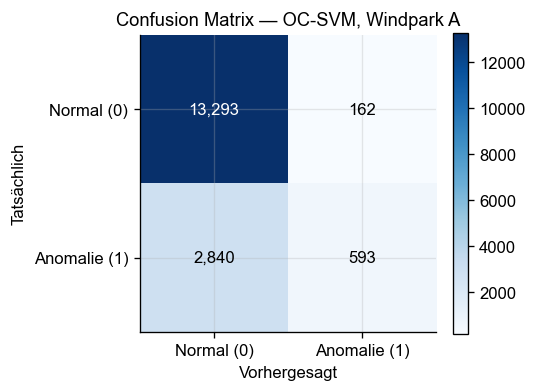

Classification Report:
              precision    recall  f1-score   support

  Normal (0)      0.824     0.988     0.899     13455
Anomalie (1)      0.785     0.173     0.283      3433

    accuracy                          0.822     16888
   macro avg      0.805     0.580     0.591     16888
weighted avg      0.816     0.822     0.773     16888

Trefferquote (Recall) je Ausfalltyp:


,Fenster,Erkannt,Recall
typ,,,
Gearbox failure,501,32,0.064
Generator bearing failure,1250,445,0.356
Hydraulic group,1323,116,0.088
Transformer failure,359,0,0.000


Fehlalarmrate im Normalbetrieb (False-Positive-Rate): 0.012
Anomalie-Events nahezu vollständig übersehen (Recall < 5 %): 5 von 11


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

FORCE = None  # z.B. ("A", "RF"), um ein bestimmtes Modell zu erzwingen; sonst automatisch bestes nach ROC-AUC

if FORCE is not None:
    bfarm, bmodel = FORCE
else:
    best = results_table.loc[results_table["ROC_AUC"].idxmax()]
    bfarm, bmodel = best["farm"], best["model"]

per   = load_scores(bfarm, bmodel)
y     = np.concatenate([r["y"] for r in per])
pred  = np.concatenate([(r["scores"] > r["thr"]).astype(int) for r in per])  
eids  = np.concatenate([r["eids"] for r in per])

print(f"Bestes Modell: {bmodel} auf Windpark {bfarm}  "
      f"(ROC-AUC={results_table.query('farm==@bfarm and model==@bmodel')['ROC_AUC'].iloc[0]})\n")

cm = confusion_matrix(y, pred, labels=[0, 1])
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Normal (0)", "Anomalie (1)"]); ax.set_yticklabels(["Normal (0)", "Anomalie (1)"])
ax.set_xlabel("Vorhergesagt"); ax.set_ylabel("Tatsächlich")
ax.set_title(f"Confusion Matrix — {bmodel}, Windpark {bfarm}")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
fig.colorbar(im, ax=ax, fraction=0.046); fig.tight_layout(); plt.show()


print("Classification Report:")
print(classification_report(y, pred, labels=[0, 1],
                            target_names=["Normal (0)", "Anomalie (1)"],
                            digits=3, zero_division=0))

typ = events.query("farm == @bfarm").set_index("event_id")["event_description"].to_dict()
df  = pd.DataFrame({"eid": eids, "y": y, "pred": pred})
df["typ"] = df["eid"].map(typ)

anom = df[df["y"] == 1]
per_typ = (anom.groupby("typ")
                .agg(Fenster=("pred", "size"), Erkannt=("pred", "sum")))
per_typ["Recall"] = (per_typ["Erkannt"] / per_typ["Fenster"]).round(3)
print("Trefferquote (Recall) je Ausfalltyp:")
display(per_typ)

fpr = (df.loc[df["y"] == 0, "pred"] == 1).mean()
per_event_recall = anom.groupby("eid")["pred"].mean()
n_missed = int((per_event_recall < 0.05).sum())
print(f"Fehlalarmrate im Normalbetrieb (False-Positive-Rate): {fpr:.3f}")
print(f"Anomalie-Events nahezu vollständig übersehen (Recall < 5 %): "
      f"{n_missed} von {anom['eid'].nunique()}")

Die Confusion Matrix zeigt, wie sich die Vorhersagen des besten Modells (OC-SVM auf Windpark A) bei der gewählten Schwelle verteilen. Von den 13.455 Normalfenstern stuft das Modell 13.293 korrekt als unauffällig ein. Die Fehlalarmrate liegt mit 1,2 % sehr niedrig. Auf der Anomalie-Seite erkennt das Modell jedoch nur 593 von 3.433 Fenstern korrekt, die restlichen 2.840 werden übersehen.

Was bedeutet das? 
Der Recall für die Anomalie-Klasse liegt bei nur 17,3 % — das Modell erkennt also nur etwa jedes sechste anomale Fenster. Die Präzision hingegen ist mit 78,5 % solide: Wenn das Modell Alarm schlägt, liegt es in knapp vier von fünf Fällen richtig. Das Modell verhält sich also konservativ. Es schlägt lieber zu selten Alarm als zu oft. Das ist eine direkte Folge der Schwelle (99. Perzentil der Trainings-Scores): Nur Fenster mit extrem hohen Anomalie-Scores werden als auffällig gewertet, alles darunter gilt als normal.

Warum werden so viele Anomalien übersehen? 
Die Degradation verläuft schleichend. Die Sensoren zeigen nicht plötzlich völlig andere Werte, sondern verändern sich über Tage nur minimal. Viele Fenster innerhalb der Prediction-Periode sehen daher noch fast genauso aus wie normaler Betrieb. Genau das, was die EDA in Abschnitt 2.5 bereits gezeigt hat: Auf Einzelzeitpunkt-Ebene kann man Normal- und Fehlerbetrieb praktisch nicht unterscheiden.

Die Aufschlüsselung je Ausfalltyp bestätigt die in der EDA vorhergesagte Schwäche. Der Transformatorausfall wird mit einem Recall von 0,000 komplett übersehen — bei nur einem einzigen Trainingsbeispiel hat das Modell keine Chance, ein übertragbares Muster für diesen Fehlertyp zu lernen. Auch die Getriebeausfälle (Recall 0,064) und die Hydraulikgruppe (0,088) werden nahezu vollständig verfehlt. Einzig die Generatorlager-Ausfälle erreichen mit 0,356 eine nennenswerte Trefferquote — vermutlich, weil sich Lagerschäden am Generator stärker in den Temperatursensoren niederschlagen und damit ein deutlicheres Signal erzeugen als die übrigen Fehlerarten.

Insgesamt werden 5 von 11 Anomalie-Events nahezu vollständig übersehen (Recall < 5 %). Das unterstreicht eine zentrale Limitation: Ein einziges Modell für alle Ausfalltypen gleichzeitig stößt an seine Grenzen, wenn sich die verschiedenen Schadensarten in ganz unterschiedlichen Sensoren und Mustern äußern.

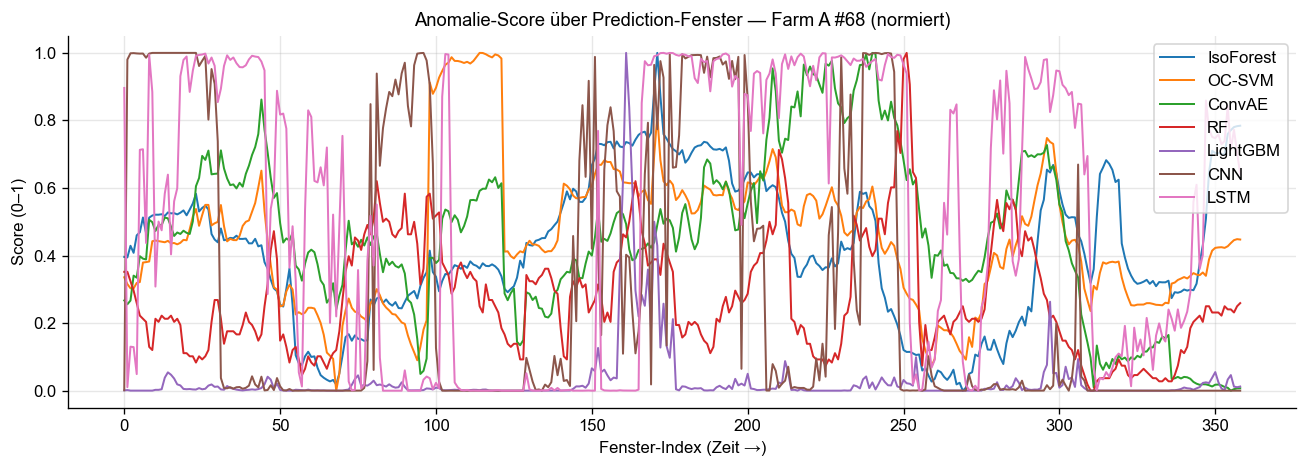

In [27]:
demo_farm = "A"; demo_eid = int(events.query("farm==@demo_farm and event_label=='anomaly'").iloc[0]["event_id"])
fig, ax = plt.subplots(figsize=(11, 4))
for model in MODELS:
    if not scores_exist(demo_farm, model): continue
    per = load_scores(demo_farm, model)
    fold = next((r for r in per if demo_eid in np.unique(r["eids"])), None)
    if fold is None: continue
    mask = fold["eids"] == demo_eid
    s = fold["scores"][mask]; s = (s - s.min()) / (np.ptp(s) + 1e-9)
    ax.plot(s, lw=1.2, label=model)
ax.set_title(f"Anomalie-Score über Prediction-Fenster — Farm {demo_farm} #{demo_eid} (normiert)")
ax.set_xlabel("Fenster-Index (Zeit →)"); ax.set_ylabel("Score (0–1)"); ax.legend(); fig.tight_layout()

Die Abbildung oben zeigt, wie die normalisierten Anomalie-Scores aller sieben Modelle über den Prediction-Zeitraum eines konkreten Anomalie-Events verlaufen. Jede Linie repräsentiert ein Modell. Im Idealfall würden die Scores zum Ende hin (näher am Ausfall) ansteigen.

In der Praxis ist das Bild deutlich unruhiger: Die Scores schwanken stark und zeigen kein klares, monotones Ansteigen. Das verdeutlicht die Schwierigkeit der Aufgabe — selbst mit Kenntnis des Ausfallzeitpunkts im Nachhinein ist es schwer, ein eindeutiges Vorwarnsignal in den Scores zu erkennen.

---

## 8 · Diskussion und Fazit

### Wurden die Ziele erreicht?

Die Forschungsfrage konnte beantwortet werden, wenn auch mit einem anderen Ergebnis als erwartet: Die explizite Modellierung der Zeitstruktur bringt auf diesem Datensatz keinen klaren Vorteil. Der Conv-Autoencoder (zeitlich) liegt auf beiden Parks hinter den tabellarischen semi-supervised Modellen (OC-SVM, Isolation Forest). Entscheidender als die Frage "tabellarisch vs. zeitlich" ist das Lernparadigma: Semi-supervised schlägt supervised auf Park A deutlich — auf Park B sind die Ansätze vergleichbar.

Das beste Einzelergebnis liefert die One-Class SVM auf Park A mit einer ROC-AUC von 0,695. Auf Park B erreicht der Conv-Autoencoder 0,599. Alle Werte bewegen sich im Bereich von 0,4 bis 0,7, was die bekannte Schwierigkeit des CARE-Benchmarks widerspiegelt.

### Was hat gut funktioniert

Die semi-supervised Modelle liefern auf beiden Parks Werte über dem Zufallsniveau. Die LOAO-Validierung verhindert eine zu optimistische Bewertung. Die Datenvorverarbeitung mit kausalen Fenstern und foldweiser Skalierung vermeidet Informationslecks. Die Fenster-Kennzahlen (7 Statistiken je Sensor) erweisen sich als effektive Komprimierung der Zeitreihen.

### Was nicht funktioniert hat

Die supervised Modelle mit Pseudo-Labels scheitern auf Park A komplett (alle unter 0,5). Die Pseudo-Label-Annahme — der gesamte Prediction-Zeitraum entspricht einer Anomalie — ist offensichtlich zu grob. Der Prediction-Zeitraum enthält vermutlich erhebliche Anteile an Normalbetrieb, die fälschlich als Anomalie gelabelt werden. Die Modelle lernen daraus verrauschte, widersprüchliche Muster und schneiden schlechter ab als Zufall.

### Limitationen

- **Wenige Anomalie-Ereignisse:** 11 in Park A, 6 in Park B — die Metriken können stark streuen.
- **Ein Seed:** Zufällige Effekte sind nicht ausgemittelt.
- **Pseudo-Labels:** Die Annahme trifft nachweislich nicht auf Park A zu und ist eine klare Schwachstelle des supervised Ansatzes.
- **LOAO leicht optimistisch:** Dieselbe Turbine kann in Training und Test vorkommen.
- **Ein Modell für alle Ausfalltypen:** Seltene Typen wie der Transformatorausfall sind im Training kaum vertreten.

### Mögliche Verbesserungen und Ausblick

- **Group-K-Fold auf Turbinen-Ebene:** Echte Übertragbarkeitsprüfung, indem eine komplette Turbine aus dem Training herausgehalten wird. War aus Zeitgründen nicht umsetzbar.
- **Mehrere Seeds:** Stabilere Ergebnisse.
- **Vollständiger CARE-Score:** Die Autoren des Datensatzes schlagen einen eigenen Score vor (Coverage, Accuracy, Reliability, Earliness), der hier noch nicht implementiert wurde.
- **Feinere Pseudo-Labels:** Statt den gesamten Prediction-Teil als Anomalie zu labeln, könnte man den Degradationsbeginn genauer eingrenzen.
- **Per-Sensor-Rekonstruktionsfehler:** Der Conv-Autoencoder könnte den Fehler pro Sensor ausgeben und so sichtbar machen, welche Sensoren eine Anomalie treiben (Erklärbarkeit).
- **LSTM-Autoencoder:** Als weiteres temporales semi-supervised Modell.

# Literatur:

Gück, C.; Roelofs, C.M.A.; Faulstich, S. (2024): CARE to Compare: A Real-World Benchmark Dataset for Early Fault Detection in Wind Turbine Data. *Data*, 9(12), 138. https://doi.org/10.3390/data9120138

# Anhang 1: Eigenständigkeitserklärung
Hiermit bestätige ich, dass ich die vorliegende Arbeit selbstständig verfasst und keine anderen Publikationen, Vorlagen und Hilfsmittel (z.B. künstliche Intelligenz) als die angegebenen benutzt habe. Alle Teile meiner Arbeit, die wortwörtlich oder dem Sinn nach anderen Werken entnommen sind, wurden unter Angabe der Quelle kenntlich gemacht. Gleiches gilt für von mir verwendete Internetquellen. Ich versichere, dass ich diese Arbeit oder nicht zitierte Teile daraus vorher nicht in einem anderen Prüfungsverfahren eingereicht habe. Mir ist bekannt, dass meine Arbeit zum Zwecke eines Plagiatsabgleichs mittels einer Plagiatserkennungssoftware auf eine ungekennzeichnete Übernahme von fremdem geistigen Eigentum sowie auf die Nutzung von künstlicher Intelligenz zur Texterstellung überprüft werden kann. Ich versichere, dass die elektronische Form meiner Arbeit mit der gedruckten Version identisch ist.

# Anhang 2: Promptverzeichnis

Dokumentation der wesentlichen Prompts, mit denen KI (Claude, Anthropic) zur Erstellung von Code und zur methodischen Klärung eingesetzt wurde. Die Prompts sind thematisch gruppiert und sinngemäß wiedergegeben.

## Projektaufbau und Datensatz

1. "Wir nutzen den CARE-Datensatz für die Windturbinen-Anomalieerkennung. Welchen Datensatz und welche Referenz sollen wir verwenden, und welche Windparks sind sinnvoll?"

2. "Windpark A hat nur wenige Anomalie-Events. Ist das Vorgehen sinnvoll, und wie sollen wir das Jupyter Notebook aufbauen?"

3. "Wie strukturieren wir das Notebook so, dass der Code im Vordergrund steht und der erklärende Text in ein separates PDF kommt?"

## Methodik und Modellauswahl

4. "Erkläre die offenen Entscheidungen bei der Modellauswahl: CNN oder LSTM, welcher Autoencoder, CV-Design bei wenigen Anomalien, Seeds, Hyperparameter."

5. "Der CARE-Trainingsteil enthält nur Normalbetrieb. Wie sollen RF, LightGBM, CNN und LSTM damit umgehen, wenn keine Anomalie-Labels zum Trainieren vorliegen?"

6. "Prüfe das Paper von Gück et al. 2024: welche Modelle und welches Lernparadigma verwenden die Autoren?"

7. "Wir wollen sowohl den paper-treuen semi-supervised Ansatz als auch einen supervised Vergleich (RF/GBM gegen CNN/LSTM) umsetzen. Wie definieren wir dafür Pseudo-Labels methodisch sauber?"

8. "Erkläre den Unterschied zwischen Group-K-Fold auf Turbinen-Ebene und Leave-One-Anomaly-Out."

## Datenvorverarbeitung und Notebook-Code

9. "Schreibe den Notebook-Code für CSV-zu-Parquet-Konvertierung und die Event-Übersicht aus event_info."

10. "Die CSVs sind semikolon-getrennt und die Zeitspalte heißt time_stamp. Passe den Lese-Code an."

11. "Schreibe Abschnitt 6: Windowing, Leave-One-Anomaly-Out-Folds und Scaling, mit Trennung von train- und prediction-Teil über die vorgegebenen Spalten."

12. "Wie trenne ich Trainings- von Prediction-Daten korrekt und filtere nur den Normalbetrieb (Status 0)?"

## Modelltraining

13. "Schreibe Abschnitt 7: semi-supervised tabellarisch mit Isolation Forest und One-Class SVM, Schwelle aus dem 99. Perzentil der Trainingsdaten."

14. "Schreibe Abschnitt 8: Conv-Autoencoder auf rohen Fenstern, Rekonstruktionsfehler als Anomalie-Score."

15. "Schreibe Abschnitt 9: supervised RF, LightGBM, 1D-CNN und LSTM mit Pseudo-Labels und Class Weights."

16. "Der Conv-Autoencoder auf Windpark B sprengt den Arbeitsspeicher (257 Features). Löse das mit einem Keras-Generator, der die Fenster batchweise erzeugt."

## Cloud-Training und Fehlerbehebung

17. "Wie trainiere ich das Notebook auf Kaggle mit GPU? Erkläre Dataset-Upload, GPU-Aktivierung und Save & Run All."

18. "Der Kernel stirbt beim Training von Windpark A in Abschnitt 7. Woran liegt das und wie behebe ich es?"

19. "Wie sichere ich die berechneten Artefakte, damit ein erneuter Lauf die bereits trainierten Modelle überspringt?"

20. "Fehler: numpy.ndarray hat kein Attribut ptp. Wie behebe ich das?"

## Auswertung

21. "Schreibe Abschnitt 10: Evaluation mit ROC-AUC und F1 je Modell je Park, Pooled Predictions, Balkendiagramm und Score-Zeitreihe."

22. "Interpretiere die Ergebnistabelle: was bedeutet das parkabhängige Bild für die Forschungsfrage?"

## Dokumentation

23. "Gleiche den bestehenden PDF-Entwurf mit dem tatsächlich gebauten Notebook ab und benenne die methodischen Abweichungen (Label-Definition, Validierung, Status-Filterung)."

24. "Formuliere den Ergebnis-, Fazit- und Limitationsteil auf Basis der tatsächlichen Resultate."

25. "Verbessere Satzbau, Grammatik, Verständlichkeit und Lesefluss ohne die Texte in irgendeinweweise inhaltlich zu verändern."

26. "Erstelle einfügefertigen Python-Code für die fehlenden Anforderungen Trainingsverlauf (Loss-/Metrik-Kurven) und Detailanalyse des besten Modells (Confusion Matrix, Classification Report, Fehleranalyse je Ausfalltyp), passend zu den bestehenden Hilfsfunktionen"

27. "Prüfe den bisherigen Dokumentationstext auf inhaltliche Fehler, Lücken und Vollständigkeit gemäß dem Anforderungskatalog der Projektarbeit und der Aufgabenstellung."

## Explorative Datenanalyse

28. "Erstelle den vollständigen EDA-Code mit allen laut Anforderungskatalog geforderten Visualisierungen: Datenqualität, Betriebszustände, Ausfalltypen, Sensorgruppen, Normal- vs. Anomaliebereiche, Korrelationsanalyse und zeitliche Muster."

29. "Überarbeite den EDA-Code auf einheitlichen Stil und ergänze fehlende Analysen wie die Korrelation einzelner Sensoren mit dem Vorlaufzeitfenster und die saisonale Verteilung der Anomalie-Events."
